# Intorduction
This project represents ML application in HR analytics, that allows business to predict employee's attitude to avoid a sudden quit of employee that may cause a financial damage to the company.
# Project objective:
Create two ML models.
1.	Model predicting job satisfaction rate (from 0 to 1) based on data provided by the customer.
2.	Model predicting sudden quit of an employee.

# Import of libraries and settings definition

In [1]:
!pip install phik -q
!pip install shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 7.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
                             r2_score, accuracy_score,
                             confusion_matrix,
                             roc_auc_score,
                             make_scorer,
                            )
from sklearn.preprocessing import (
                                    StandardScaler,
                                    MinMaxScaler,
                                    OneHotEncoder,
                                    OrdinalEncoder,
                                    LabelEncoder
                                   )
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import phik
plt.rcParams['font.size'] = 18.0
plt.rcParams.update({'axes.titlesize': 'large'})
sns.set_context(
                'notebook',
                rc={
                    'font.size': 15,
                    'axes.titlesize': 10,
                    'xtick.labelsize': 'small',
                    'ytick.labelsize': 'small',
                    'legend.fontsize': 'small',
                    'legend.title_fontsize': 10
                }
            )
RANDOM_STATE = 50

# 1. Model predicting job satisfaction rate

In this chapter model predicting job satisfaction rate is created.
<br> The target value changes from "0" to "1" in continious manner which means that model should be used for regression type of problem.

## 1.1 Dataset review

In this section customer data is loaded and preprocessed for further work.

### 1.1.1 Data import

<br>The training set is in train_job_satisfaction_rate.csv
<br>
<br>Test features are in test_features.csv
<br>
<br>Target feature for the test set is in test_target_job_satisfaction_rate.csv

The following set of features was provided by the customer:
* id — unique id of the employee;
* dept — department of the employee;
* level — level of the employee;
* workload — current workload of the employee;
* employment_years — years of employment in the company;
* last_year_promo — last year promotion of the employee;
* last_year_violations — last year violations of the employee;
* supervisor_evaluation — grade of the employee given by the supervisor;
* salary — mounthly salary if the employee;
* job_satisfaction_rate — job satisfaction rate of the employee as a target variable / feature.


Reading the data:

In [3]:
try:
	train_js_rate_df = pd.read_csv('/datasets/train_job_satisfaction_rate.csv', sep=',')
	test_featrues_df = pd.read_csv('/datasets/test_features.csv', sep=',')
	test_target_df = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv', sep=',')
except:
	train_js_rate_df = pd.read_csv('https://code.s3.yandex.net/datasets/train_job_satisfaction_rate.csv', sep=',')
	test_featrues_df = pd.read_csv('https://code.s3.yandex.net/datasets/test_features.csv', sep=',')
	test_target_df = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_job_satisfaction_rate.csv', sep=',')

Check data import:

In [4]:
train_js_rate_df.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


Replacing typo in 'level' column:

In [5]:
train_js_rate_df['level'] = train_js_rate_df['level'].str.replace('sinior', 'senior')
train_js_rate_df['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

In [6]:
test_featrues_df.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [7]:
test_featrues_df['level'] = test_featrues_df['level'].str.replace('sinior', 'senior')
test_featrues_df['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

In [8]:
test_target_df.head()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


### 1.1.2 Data preprocessing

In this section I check data type for correctness of the feature described, missing values and duplicates.
<br> This steps are requred for further data investigation and check.

#### Data Frame "train_js_rate_df"

In [9]:
train_js_rate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


Data types are correct. Missing data found. Show missing data information:

In [10]:
train_js_rate_df.isna().sum()

,0
id,0
dept,6
level,4
workload,0
employment_years,0
last_year_promo,0
last_year_violations,0
supervisor_evaluation,0
salary,0
job_satisfaction_rate,0


Missing data percentage is low. Show rows with missing data:

In [11]:
train_js_rate_df[train_js_rate_df['dept'].isna()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1526,694746,NaN,junior,medium,5,no,no,4,21600,0.62
1630,814624,NaN,junior,medium,3,no,no,4,24000,0.88
1633,475114,NaN,junior,high,4,no,no,4,31200,0.63
2781,497243,NaN,junior,medium,1,no,no,3,26400,0.28
2975,168668,NaN,junior,low,3,no,no,4,18000,0.88
3866,641150,NaN,junior,low,3,no,yes,4,12000,0.54


In [12]:
train_js_rate_df[train_js_rate_df['level'].isna()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,631073,sales,NaN,medium,1,no,no,4,27600,0.66
1469,416327,sales,NaN,low,1,no,no,5,18000,0.73
1745,135043,sales,NaN,medium,1,no,no,3,26400,0.30
2522,998838,sales,NaN,medium,1,no,no,5,27600,0.71


All missing vlues will be filled using pipeline (for trainig purpose only).
<br> Both columns containing missing values are categorial features. <br> Use mode value for filling missing values.

In [13]:
na_fill_pipe = Pipeline(
    [
      (
       'sim_imp',
       SimpleImputer(missing_values=np.nan, strategy='most_frequent')
      )
    ]
)

Make a list of column names containign missing values:

In [14]:
train_js_na_col = ['dept', 'level']

Apply pipeline for filling missing values:

In [15]:
data_fill_na = ColumnTransformer(
     [
      ('fill_na', na_fill_pipe, train_js_na_col)
     ],
     remainder = 'passthrough'
)

In [16]:
data_fill_na.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('fill_na',
                                 Pipeline(steps=[('sim_imp',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['dept', 'level'])])

In [17]:
train_js_rate_rev_df = data_fill_na.fit_transform(train_js_rate_df)

Check that missing data is absent:

In [18]:
train_js_rate_rev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   fill_na__dept                     4000 non-null   object 
 1   fill_na__level                    4000 non-null   object 
 2   remainder__id                     4000 non-null   int64  
 3   remainder__workload               4000 non-null   object 
 4   remainder__employment_years       4000 non-null   int64  
 5   remainder__last_year_promo        4000 non-null   object 
 6   remainder__last_year_violations   4000 non-null   object 
 7   remainder__supervisor_evaluation  4000 non-null   int64  
 8   remainder__salary                 4000 non-null   int64  
 9   remainder__job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


Pipline changed column names. Go back to the initial column names without pre-fixes:

In [19]:
train_js_rate_rev_df.columns = train_js_rate_rev_df.columns.str.replace('fill_na__', '')
train_js_rate_rev_df.columns = train_js_rate_rev_df.columns.str.replace('remainder__', '')

Check how missing values were filled:

In [20]:
train_js_rate_rev_df[train_js_rate_df['dept'].isna()]

,dept,level,id,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1526,sales,junior,694746,medium,5,no,no,4,21600,0.62
1630,sales,junior,814624,medium,3,no,no,4,24000,0.88
1633,sales,junior,475114,high,4,no,no,4,31200,0.63
2781,sales,junior,497243,medium,1,no,no,3,26400,0.28
2975,sales,junior,168668,low,3,no,no,4,18000,0.88
3866,sales,junior,641150,low,3,no,yes,4,12000,0.54


In [21]:
train_js_rate_rev_df[train_js_rate_df['level'].isna()]

,dept,level,id,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,sales,junior,631073,medium,1,no,no,4,27600,0.66
1469,sales,junior,416327,low,1,no,no,5,18000,0.73
1745,sales,junior,135043,medium,1,no,no,3,26400,0.30
2522,sales,junior,998838,medium,1,no,no,5,27600,0.71


All missing values are filled. Good to go.

#### Data Frame "test_featrues_df"

In [22]:
test_featrues_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


All data types are correct.
<br>As one can see the data frame has missing values in the same columns as in "train_js_rate_df". Fill missing values using the same approch as above.

In [23]:
test_featrues_df.isna().sum()

,0
id,0
dept,2
level,1
workload,0
employment_years,0
last_year_promo,0
last_year_violations,0
supervisor_evaluation,0
salary,0


In [24]:
test_featrues_rev_df = data_fill_na.fit_transform(test_featrues_df)

Check pipeline work:

In [25]:
test_featrues_rev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   fill_na__dept                     2000 non-null   object
 1   fill_na__level                    2000 non-null   object
 2   remainder__id                     2000 non-null   int64 
 3   remainder__workload               2000 non-null   object
 4   remainder__employment_years       2000 non-null   int64 
 5   remainder__last_year_promo        2000 non-null   object
 6   remainder__last_year_violations   2000 non-null   object
 7   remainder__supervisor_evaluation  2000 non-null   int64 
 8   remainder__salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


Return to original column names:

In [26]:
test_featrues_rev_df.columns = test_featrues_rev_df.columns.str.replace('fill_na__', '')
test_featrues_rev_df.columns = test_featrues_rev_df.columns.str.replace('remainder__', '')

Final check of missing values filling:

In [27]:
test_featrues_rev_df.head()

,dept,level,id,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,marketing,junior,485046,medium,2,no,no,5,28800
1,hr,junior,686555,medium,1,no,no,4,30000
2,sales,middle,467458,low,5,no,no,4,19200
3,sales,middle,418655,low,6,no,no,4,19200
4,hr,middle,789145,medium,5,no,no,5,40800


#### Data Frame "test_target_df"

In [28]:
test_target_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


In [29]:
test_target_df.head()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


It can be noted that 'id' index for test dataframe with input fetures doesnt match 'id' index for test dataframe with target value. Merge dataframes by 'id' column:

In [30]:
test_full = test_featrues_rev_df.merge(test_target_df, on='id')
test_full.head()

,dept,level,id,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,marketing,junior,485046,medium,2,no,no,5,28800,0.79
1,hr,junior,686555,medium,1,no,no,4,30000,0.72
2,sales,middle,467458,low,5,no,no,4,19200,0.64
3,sales,middle,418655,low,6,no,no,4,19200,0.60
4,hr,middle,789145,medium,5,no,no,5,40800,0.75


All data preprocessing procedures are complete. Good to go for data investigation.

## 1.2 Data Investigation section

### 1.2.1 Training data set analysis

Output histograms for preliminary data analysis. This is for first data review, in sections below each feature is reviewed separately.
Bar plots are used to visualize discrete features.

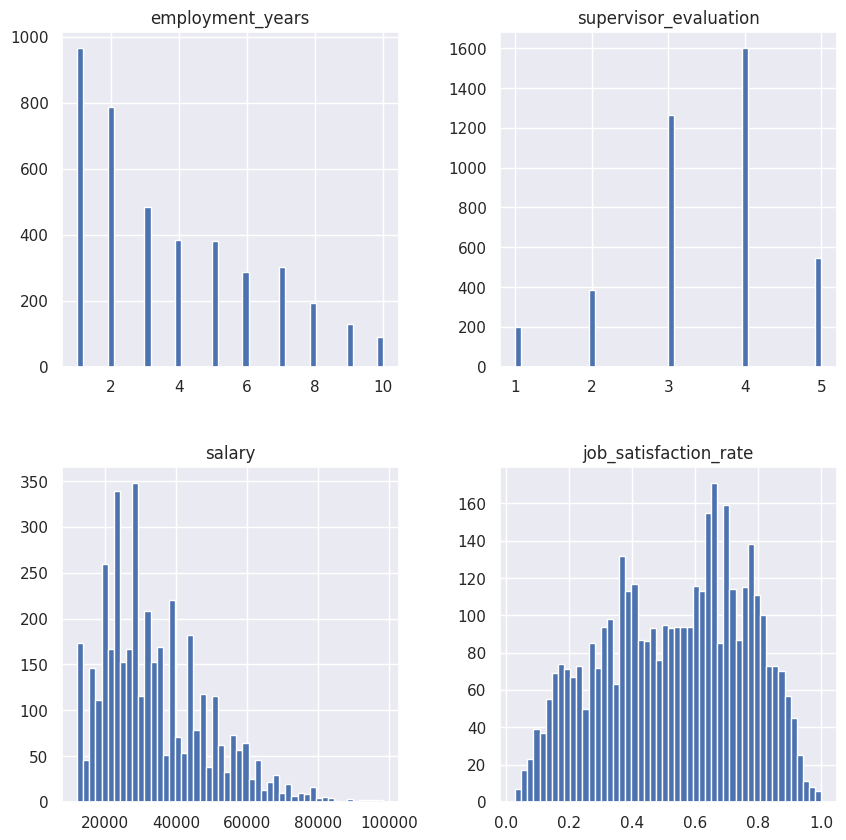

In [31]:
#plt.rcParams["figure.figsize"] = (10, 10)
sns.set (rc = {'figure.figsize':(10, 10)})
train_js_rate_rev_df.drop('id', axis=1).hist(bins=50);

From the first perception features employment_years, supervisor_evaluation and  job_satisfaction_rate have no anomalies, however salary feture should be investigated more thoroughly.

Make separate lists with column names containing numerical and categorial features.

In [32]:
descr_col = ['employment_years', 'supervisor_evaluation']
cat_col = ['dept',	'level',	'workload',	'last_year_promo',	'last_year_violations']

Make a list of colors used for histograms and plots.

In [33]:
color = ['blue', 'cyan', 'green', 'aquamarine', 'greenyellow', 'yellow' ]

Investigate employment_years and supervisor_evaluation. Make bar plots and pie charts to visualize the data.

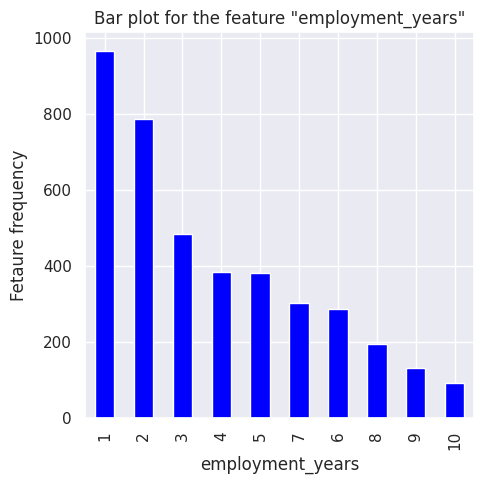

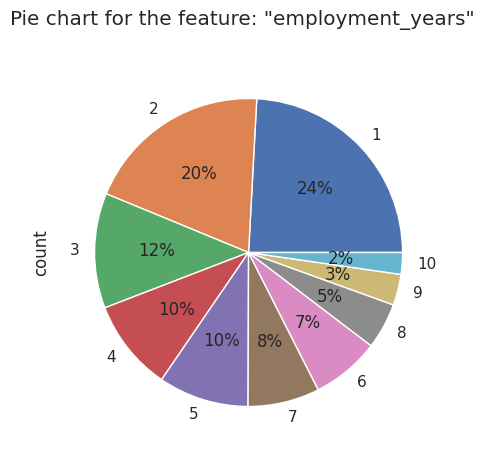

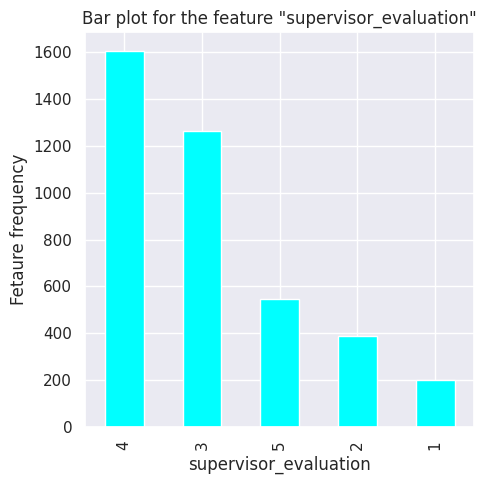

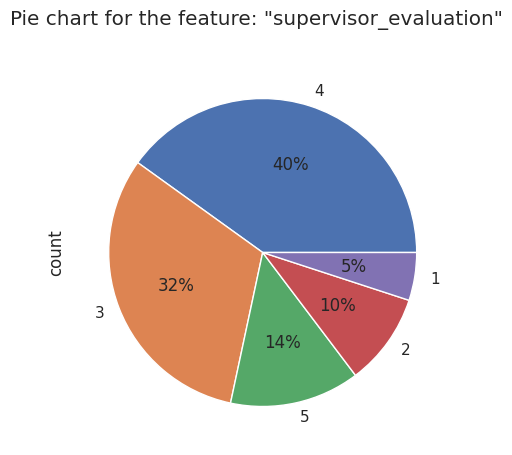

In [34]:
for i in range(len(descr_col)):
    plt.rcParams['figure.figsize'] = [5, 5]
    plt_name = 'Bar plot for the feature "' + descr_col[i] + '"'
    train_js_rate_rev_df[descr_col[i]].value_counts().plot(
                kind='bar',
                xlabel = descr_col[i],
                ylabel = 'Fetaure frequency',
                title=plt_name,
                color = color[i]
              );
    plt.tight_layout()
    plt.show()
    train_js_rate_rev_df[descr_col[i]].value_counts().plot(
        kind='pie', autopct='%.0f%%');
    title = 'Pie chart for the feature: "' + descr_col[i] + '"'
    plt.suptitle(title)
    plt.show()
    print()

Plots show that more than 900 employees work for 1 year, approximately 800 employees work for 2 years, 500 - 3 years. This means that 50% of all employees work for 1 to 3 years.
There are 100 employees (2%) with 10 work years in the company.
<br>Employee work quality assesment shows that about 1600 of them (40% of all) got grade "4" (good work) and about  1200 of employees got "3" (average work). It is shown that 15% of employees show poor quality and 5% (200 people) among them had very poor work quality results.

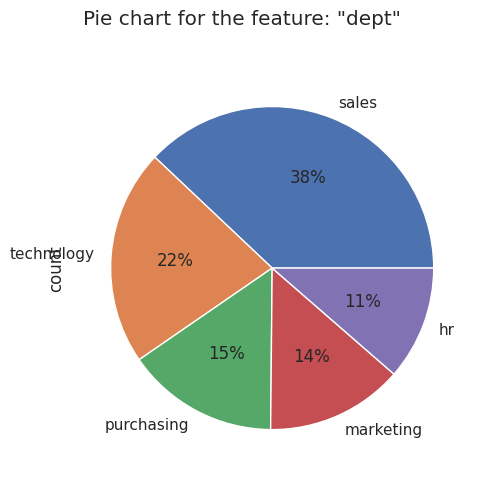

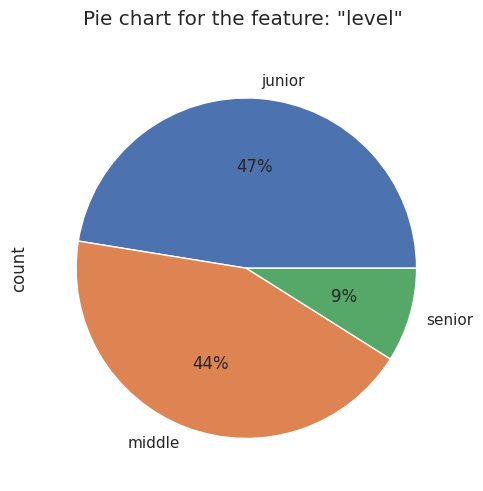

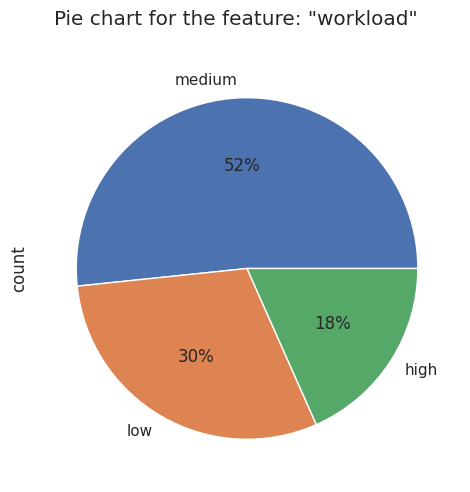

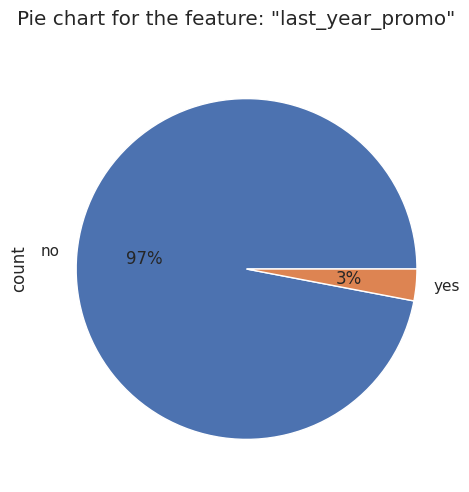

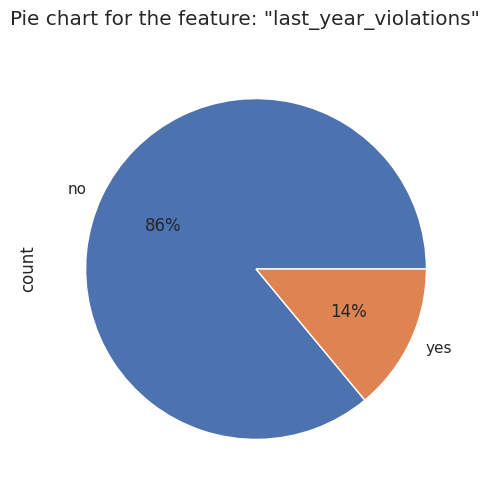

In [35]:
for i in range(len(cat_col)):
    plt.rcParams['figure.figsize'] = [5, 5]
    train_js_rate_rev_df[cat_col[i]].value_counts().plot(kind='pie', autopct='%.0f%%');
    title = 'Pie chart for the feature: "' + cat_col[i] + '"'
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    print() # для отделения графиков


The company departments include 38% of people in sales, 22% of people in technologies. The rest are purchasing, marketing and hr departments in almost equal portions.
<br> Plots show that 47% of employees are junior level, 44% are middle level, 9% are seniors. The "dept" will be coded using OrdinalEncoder since levels are ranking.
<br> As for workload it is shown that 52% of employees have medium load, 30% are low, 18% are overloaded. This feature is also ranking and will be coded with OrdinalEncoder.
<br> Last year promotion feature shows that only 3% of employees got it.
<br> However violations were found for 14% of employees.


Plot pie charts to visalize employee's workload.

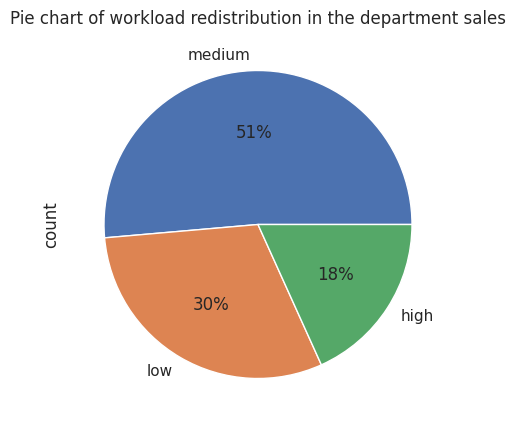

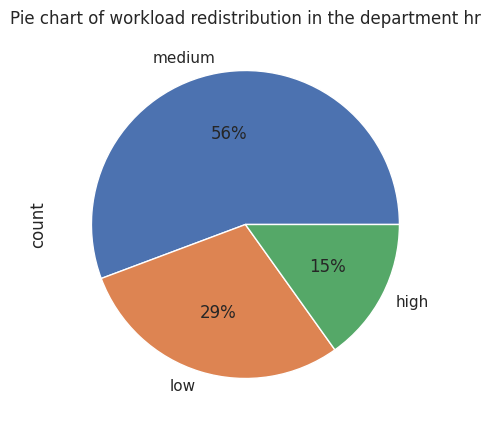

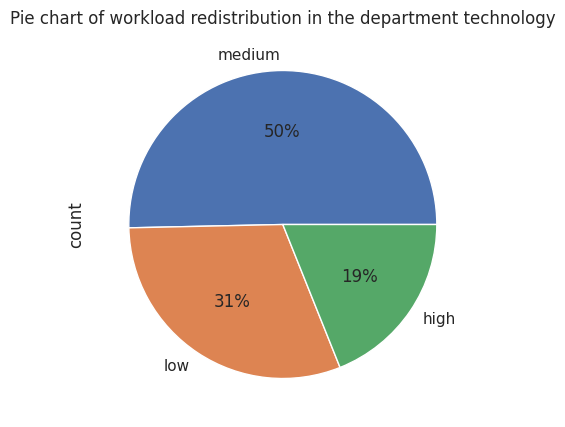

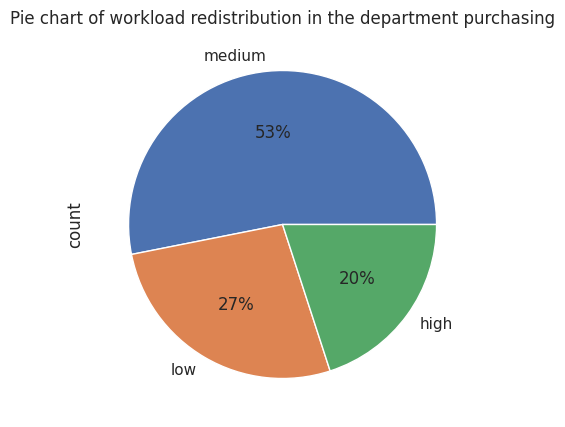

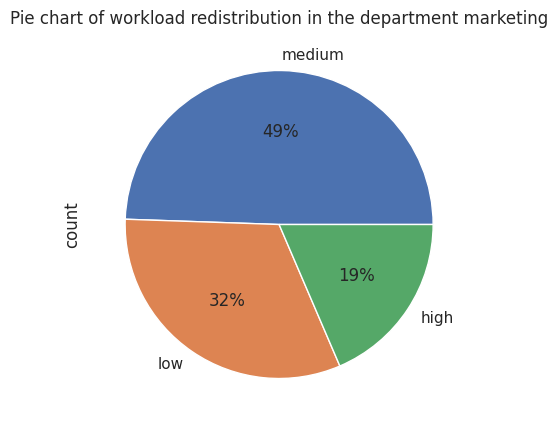

In [36]:
for elm in train_js_rate_rev_df['dept'].unique():
    plt.rcParams['figure.figsize'] = [5, 5]
    train_js_rate_rev_df[train_js_rate_rev_df['dept'] == elm]['workload'].\
      value_counts().plot(
          kind='pie',
          autopct='%.0f%%'
          );
    title = 'Pie chart of workload redistribution in the department ' + elm
    plt.title(title)
    plt.show()
    print() # для отделения графиков


Analyzing data by department it is shown that:
* 27% to 32% of employees have low workload;
* 49 to 56% have medium workload;
* 15 to 20% have high workload.
Purchasing department has the highest percent of loaded employees (20%). Meanwhile, Marketing department has the highest percentage of low workload (32%) among all.


Investigate salary for each department and level of employee. Histograms are plotted to by department groupping employees by their level:

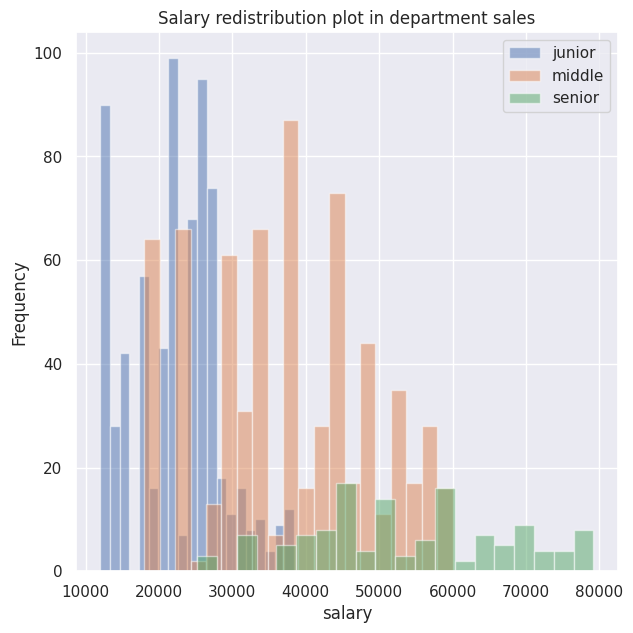

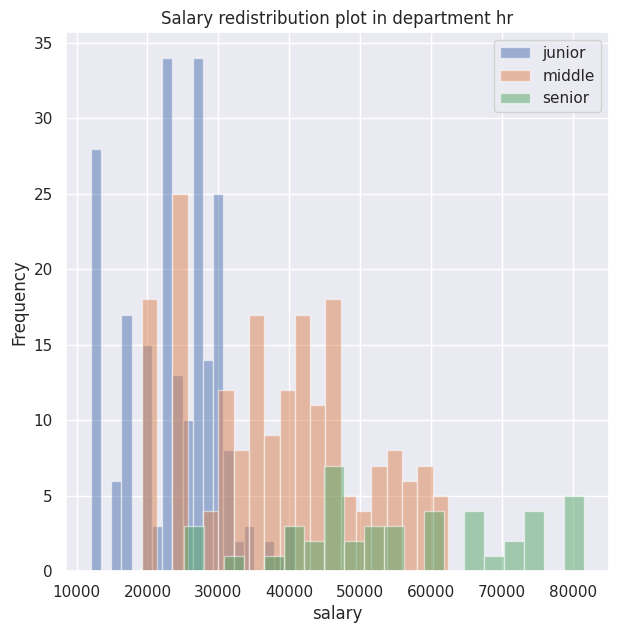

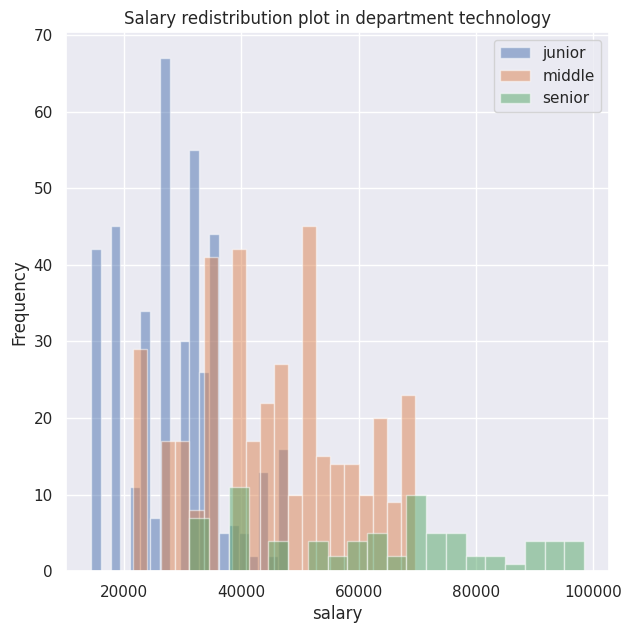

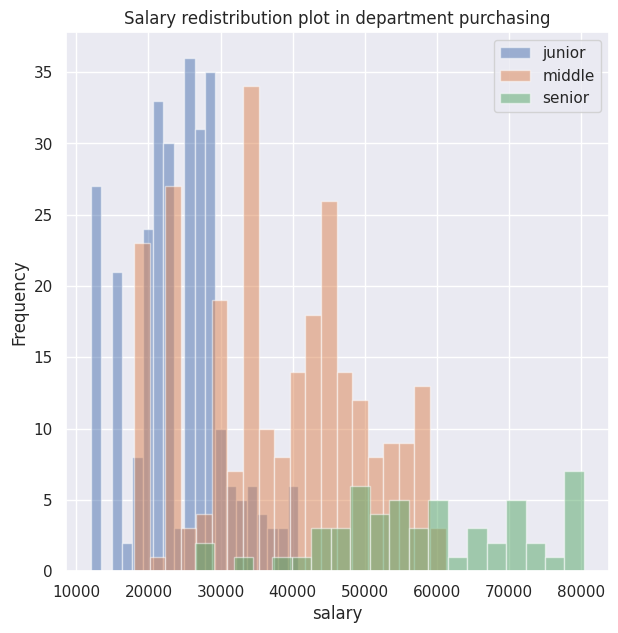

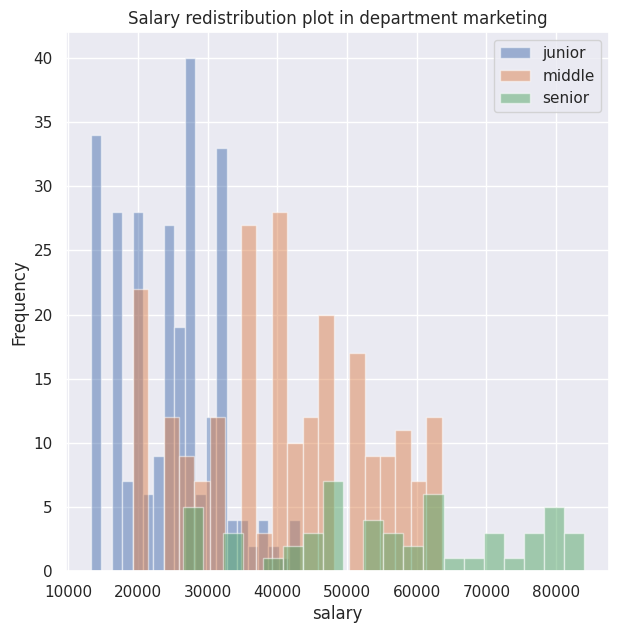

In [37]:
depts = train_js_rate_rev_df['dept'].unique()
for elm in depts:
    title_salary = 'Salary redistribution plot in department ' + elm
    train_js_rate_rev_df[train_js_rate_rev_df['dept'] == elm].groupby('level')['salary'].plot(
      kind='hist',
      bins=20,
      figsize=(7, 7),
      xlabel='salary',
      alpha = 0.5,
      title=title_salary,
      legend=True
    );
    plt.show();
    print()


Histograms illustrate common zones with salary levels of employees having different position levels.
There is no normal distribution found. Also it can be noted that there are not  much of employees with senior level and high salary.


Output a pivot table with maximum, average and minimum salary levels by department and employee level:

In [38]:
pt_salary_dept = train_js_rate_rev_df.pivot_table(index='dept', columns='level', values='salary', aggfunc=('min', 'mean', 'max'))
pt_salary_dept

max                        mean                              \
level      junior middle senior        junior        middle        senior   
dept                                                                        
hr          40800  62400  81600  23647.706422  38623.834197  55946.666667   
marketing   43200  63600  84000  24315.555556  41117.180617  56513.207547   
purchasing  40800  61200  80400  23827.986348  38116.030534  58538.181818   
sales       38400  60000  79200  22083.734088  37358.357771  54000.000000   
technology  48000  69600  98400  28340.487805  44760.000000  63315.789474   

              min                
level      junior middle senior  
dept                             
hr          12000  19200  25200  
marketing   13200  19200  26400  
purchasing  12000  18000  26400  
sales       12000  18000  25200  
technology  14400  21600  31200

Average salary level for each department are comparable by the level of employee.
Plots show that maximum salary of junior level employee is higher than the avarage salary of the midlle level employee. Moreover minimum salary in each department grows along with level of worker. This means that salary value consists of fixed value and bonuses and that explians overlapping of salary distribution on histograms for different levels in each department.

Analyze target feature:

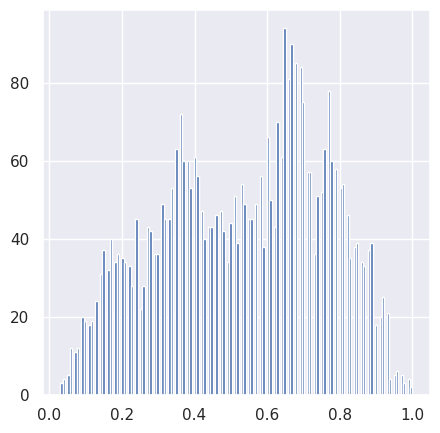

In [39]:
train_js_rate_rev_df['job_satisfaction_rate'].hist(bins=150);

The distribution shown above is multimodal. There are no drop-offs. The feature has continius distribution.

Visialize target feature distribution by departments and employee levels.

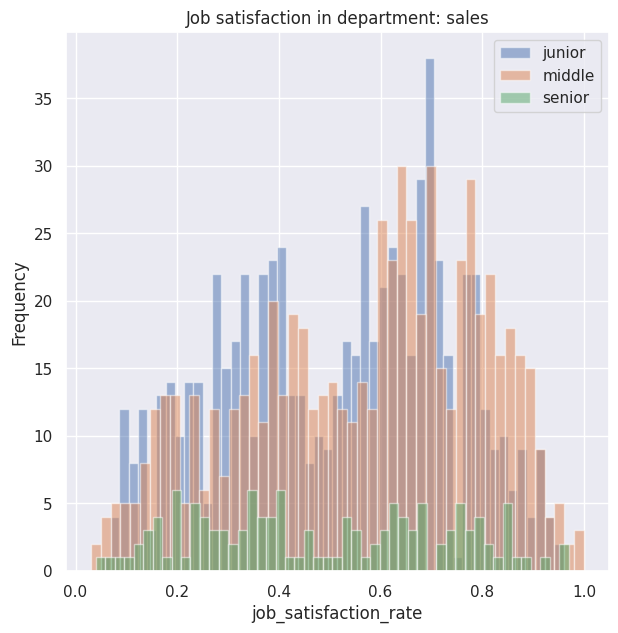

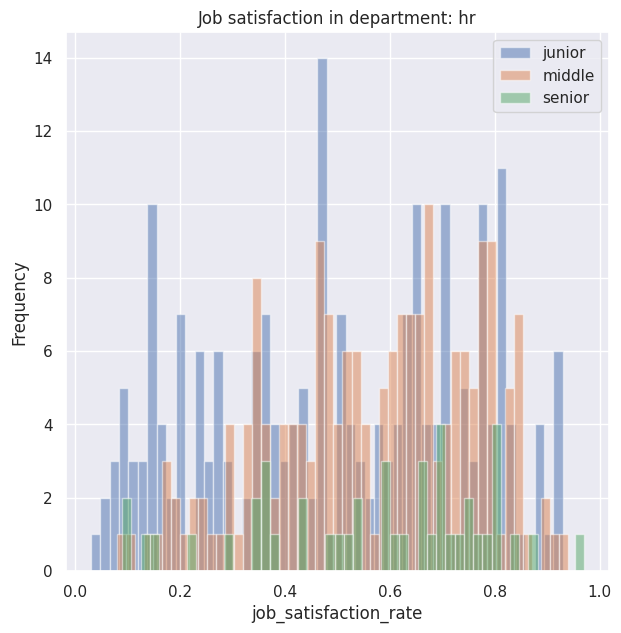

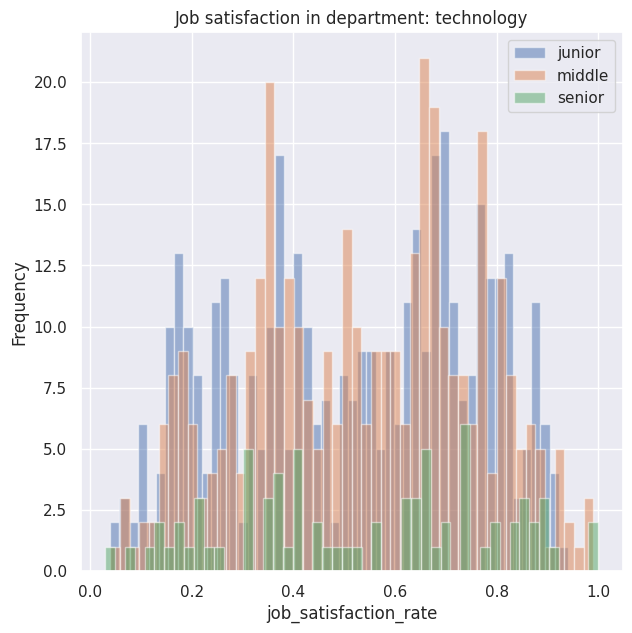

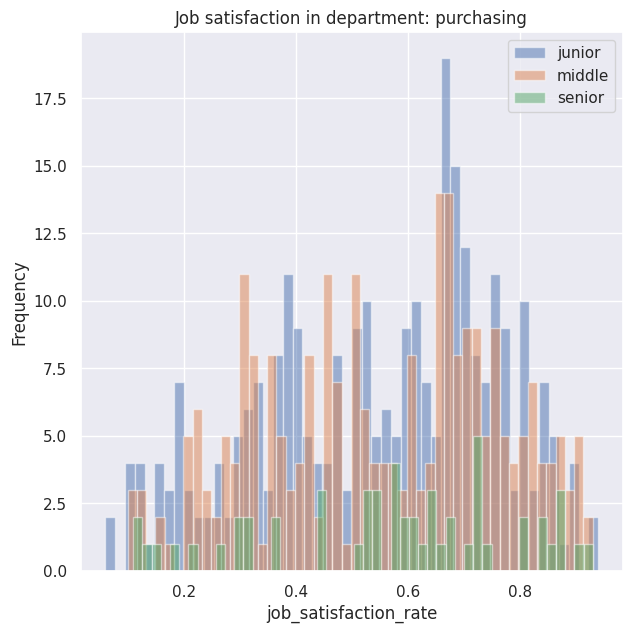

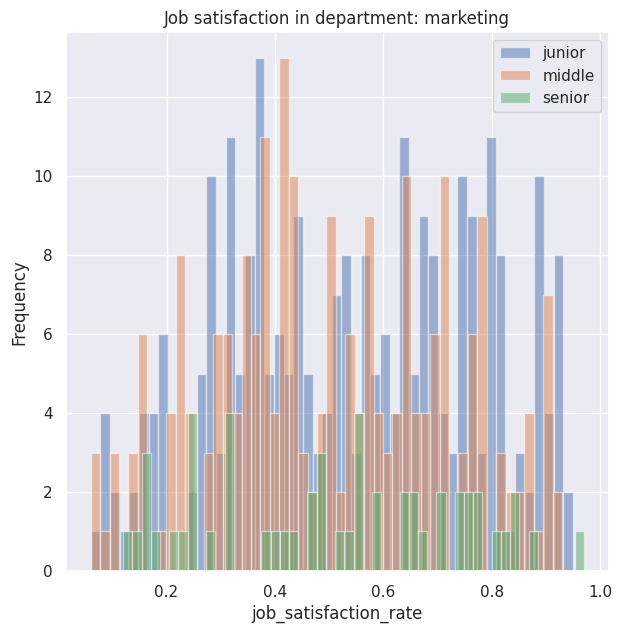

In [40]:
for elm in depts:
    title_salary = 'Job satisfaction in department: ' + elm
    train_js_rate_rev_df[train_js_rate_rev_df['dept'] == elm].groupby('level')['job_satisfaction_rate'].plot(
        kind='hist',
        bins=50,
        figsize=(7, 7),
        xlabel='job_satisfaction_rate',
        alpha = 0.5,
        title=title_salary,
        legend=True
        );
    plt.show();
    print()

Plots above show that each level has a multimodal destribution of target feature in every department investigated.

### 1.2.2 Test data set analysis

Plot data for employment_years and supervisor_evaluation features:

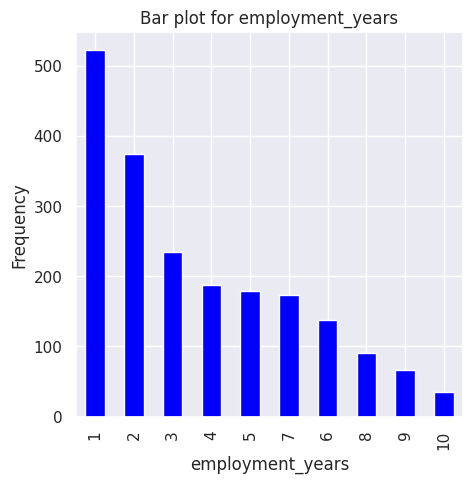

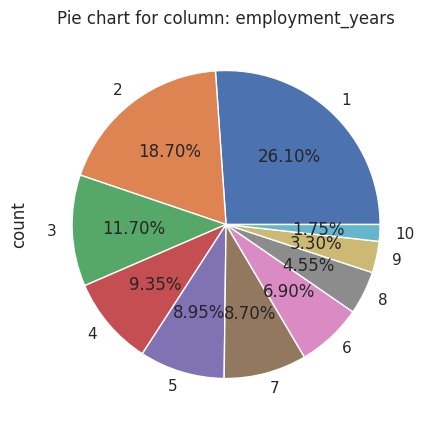

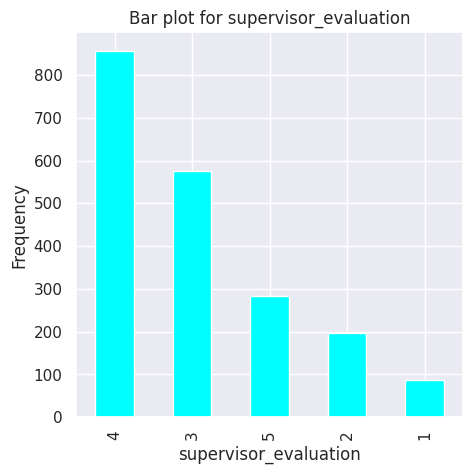

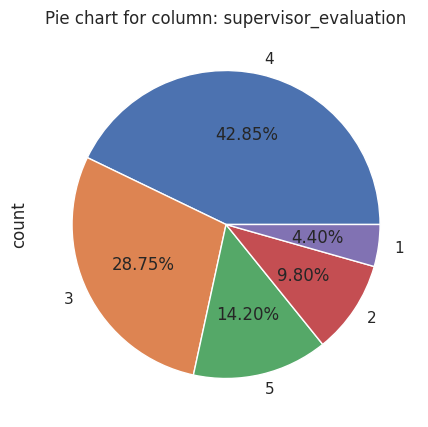

In [41]:
for i in range(len(descr_col)):
    plt.rcParams['figure.figsize'] = [5, 5]
    plt_name = 'Bar plot for ' + descr_col[i]
    test_full[descr_col[i]].value_counts().plot(
                kind='bar',
                xlabel = descr_col[i],
                ylabel = 'Frequency',
                title=plt_name,
                color = color[i]
              );
    plt.show()
    print()
    test_full[descr_col[i]].value_counts().plot(
        kind='pie', autopct='%.2f%%');
    title = 'Pie chart for column: ' + descr_col[i]
    plt.title(title)
    plt.show()
    print()

The analyzed features have the same distribution as in training dataset.

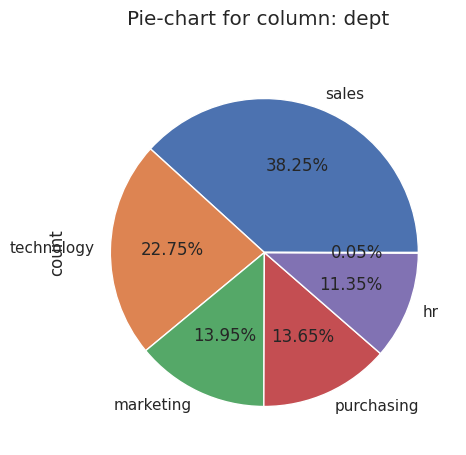

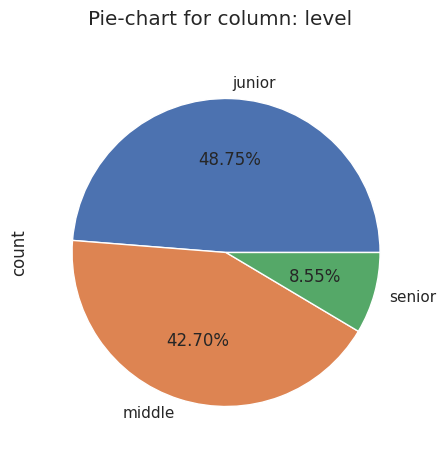

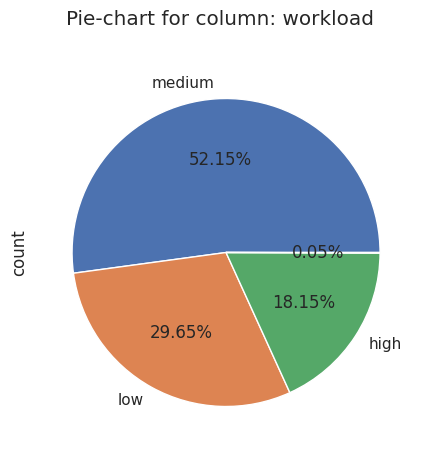

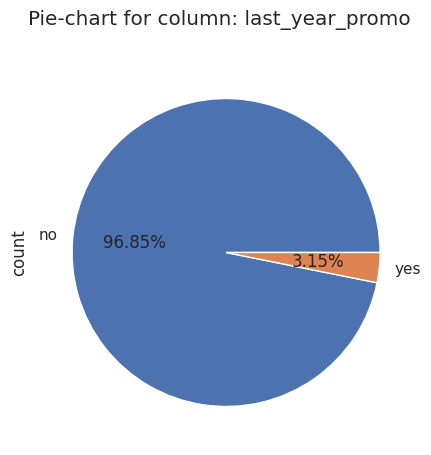

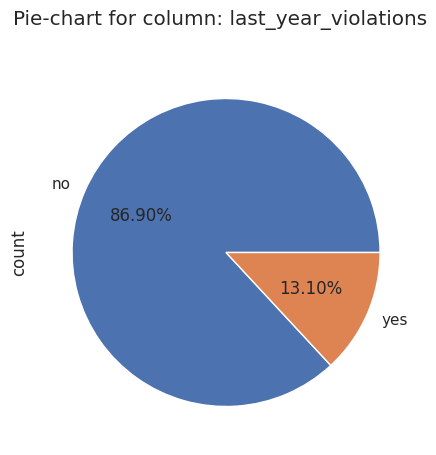

In [42]:
for i in range(len(cat_col)):
    plt.rcParams['figure.figsize'] = [5, 5]
    test_full[cat_col[i]].value_counts().plot(kind='pie', autopct='%.2f%%');
    title = 'Pie-chart for column: ' + cat_col[i]
    plt.suptitle(title)
    plt.show()
    print()

There are suspicious values for features "dept" and "workload". Output unque values for these columns:

In [43]:
test_full['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', ' '],
      dtype=object)

In [44]:
test_full['workload'].unique()

array(['medium', 'low', 'high', ' '], dtype=object)

Both columns contain value ' ', which can be replaced by np.nan temporarly. After that it will be replaced by mode using pipeline with simple omputer.

In [45]:
test_full[['dept', 'workload']] = test_full[['dept', 'workload']].replace(' ', np.nan)
test_full.isna().sum()

,0
dept,1
level,0
id,0
workload,1
employment_years,0
last_year_promo,0
last_year_violations,0
supervisor_evaluation,0
salary,0
job_satisfaction_rate,0


Checkout the distribution of employee salary to make sure it has no significant difference with training dataset.

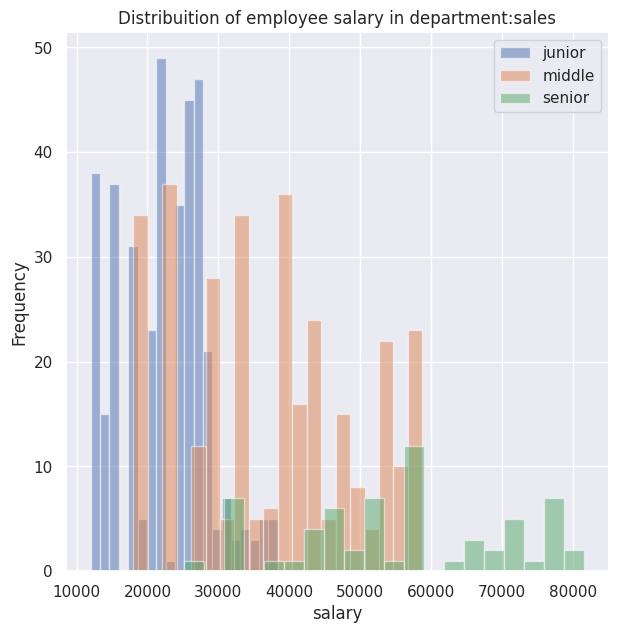

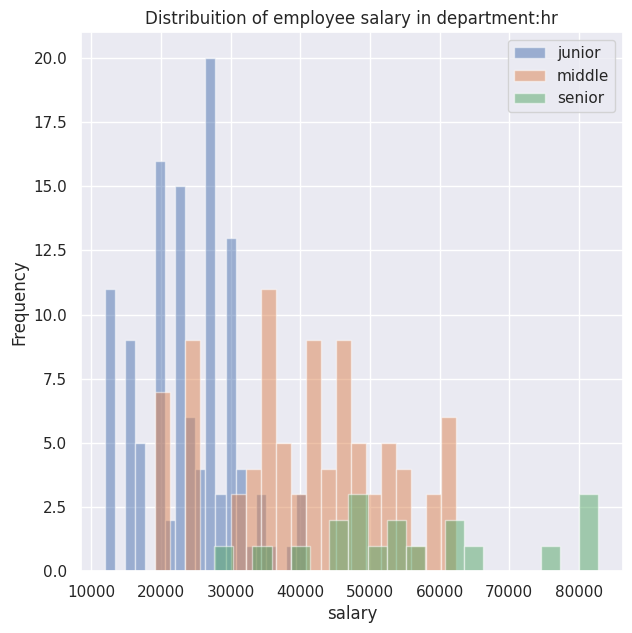

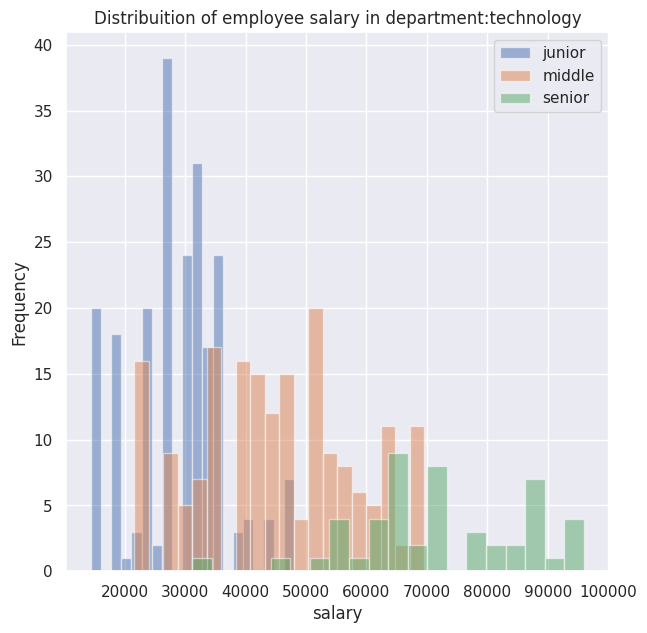

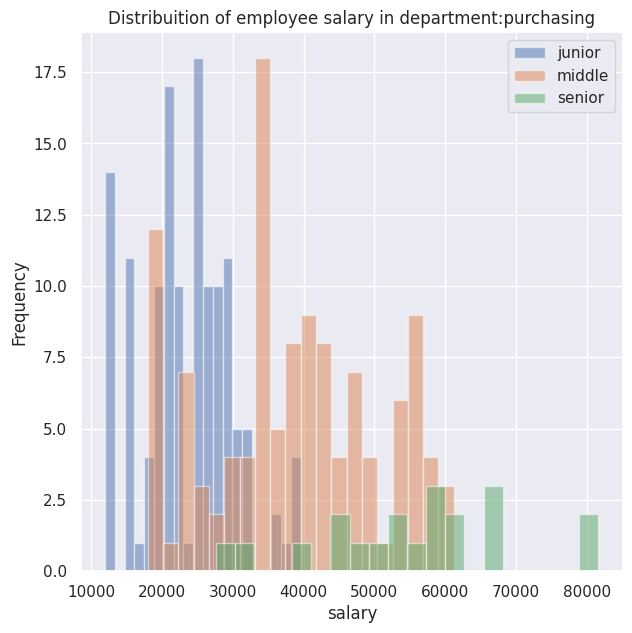

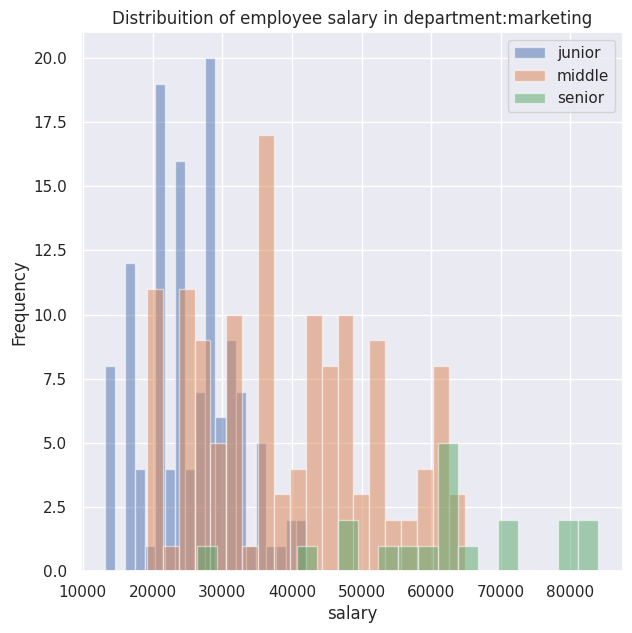

In [46]:
for elm in depts:
    title_salary = 'Distribuition of employee salary in department:' + elm
    test_full[test_featrues_rev_df['dept'] == elm].groupby('level')['salary'].plot(
        kind='hist',
        bins=20,
        figsize=(7, 7),
        xlabel='salary',
        alpha = 0.5,
        title=title_salary,
        legend=True
    );
    plt.show();
    print()

Distribution of salary is similar to test dataset.

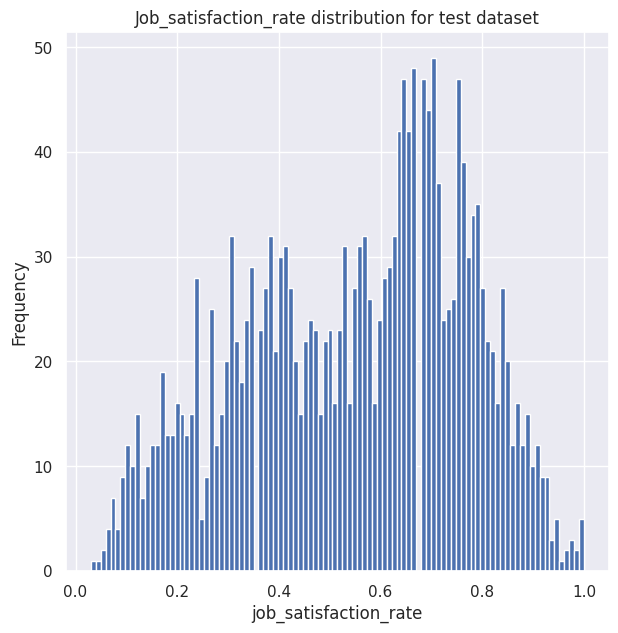

In [47]:
test_full['job_satisfaction_rate'].plot(
      kind='hist',
      bins=100,
      figsize=(7, 7),
      xlabel='job_satisfaction_rate',
      title='Job_satisfaction_rate distribution for test dataset',
    );

No anaomalies found for target feature.

### 1.2.3 Data analysis Counclusions


Analysis conducted above concludes the following findings:
1. Half of employees work up to 3 years in the company. Meanwhiel there are only 2% of employees with 10 years of work in the company.
2. About 200 employees (10%) show poor work quality, and 5% show very low results.
3. According to provided data the sales department is the biggest one. The smallest department is hr.
4. According to the workload data 52% of employees have an average level of workload. Meanwhile 30% have a low level which is a big number. There are 18% of overloaded mployees.
5. Only 3% of employees got a promotion last year. This feature usually impacts a satisfaction level of people.
6. Average salaries of employees by their level are comparable for each department. Salary consists of fixed value and bonuses. Average salary increases with the level of the employee. Histograms showed overlapping of salaries of employees having different levels in one department due to different fixed and bonus size.
7. Target feature has a multimodal distribution in general and by department.
<br> During data analysis it was found that level and workload features should be coded with ordinal encoder.
<br> There is no need for supervisor_evaluation feature coding.
<br> All other features will be coded using OneHotEncoder.
<br> Test dataset analysis showed that features "dept", "workload" contain value  ' ' that should be replaced. This will impact pipeline structure

## 1.3 Data correlation analysis

Output of Phik correlation matrix that shows correlation coefficients:

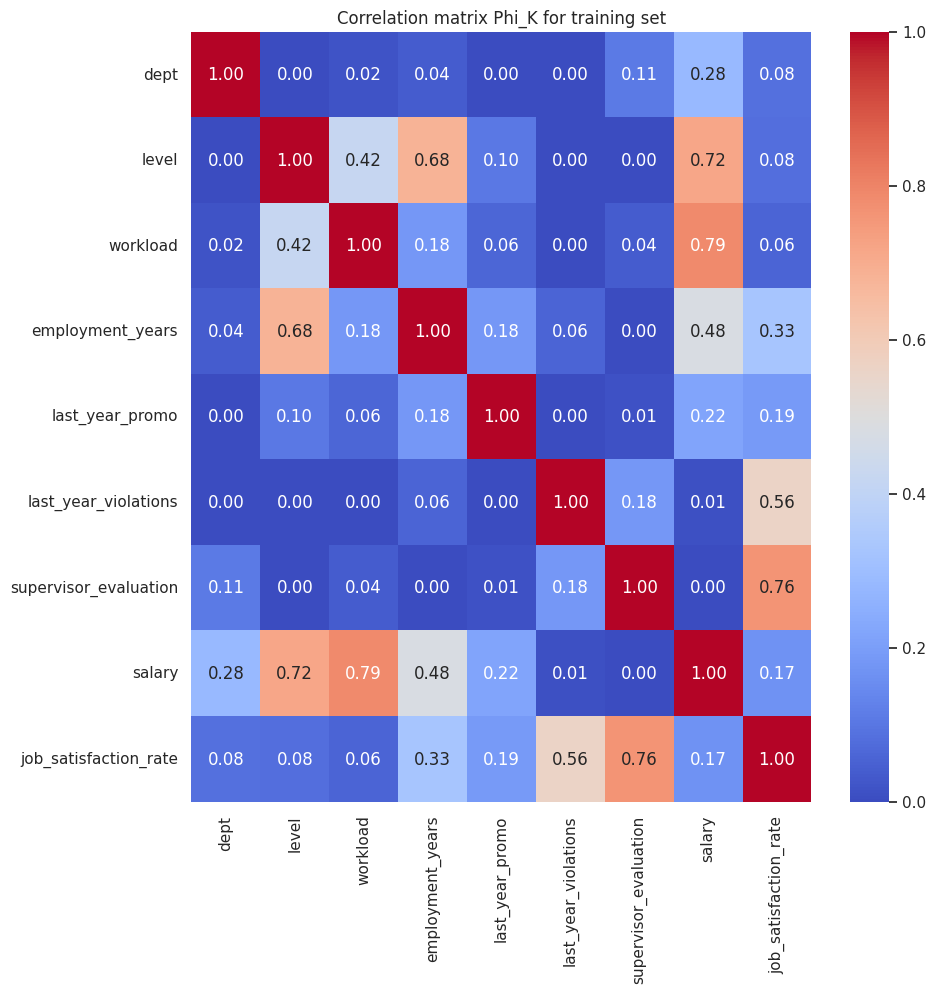

In [48]:
sns.set (rc = {'figure.figsize':(10, 10)})
plt.title('Correlation matrix Phi_K for training set')
sns.heatmap(
    train_js_rate_rev_df.drop('id', axis=1)\
    .phik_matrix(
      interval_cols=['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']
    ), annot=True, fmt='.2f', cmap='coolwarm'
);
plt.show();

One can see that target feature correlates with supervisor_evaluation feature, coefficient is 0.76.Feature last_year_violations correlates with coefficient 0.56. Last_year_promo has poor correlation.
<br> 'Level' and 'salary' feature show correlation. This supports a conlusion made in data analysis section. Moreover, a correlation coeffitient between 'level' and 'employment_years' is 0.68, which makes sense.
<br> Plot shows that 'workload' feature correlates with 'salary' feature, a coefficient is 0.79. This supports a conclusion that salary consists of fixed value and bonuses calculated based on work results.
<br> Based on plot there is no department where all employees have high job satisfaction value.

Conclusion: based on correlation analysis primary features impacting target are 'supervisor_evaluation', 'last_year_violations'. It is uclear why 'workload' feature has poor correlation. Model feature importance output will show features impact.

## 1.4 Training data preparation

 Since the provided data are already divided into training and test sets, train test split step is ommited. Feature 'id' should be removed form data:

In [49]:
X_train = train_js_rate_rev_df.drop(['id', 'job_satisfaction_rate'], axis=1)
X_test = test_full.drop(['id', 'job_satisfaction_rate'], axis=1)
y_train = train_js_rate_rev_df['job_satisfaction_rate']
y_test = test_full['job_satisfaction_rate']

In [50]:
 train_js_rate_rev_df.drop('id', axis=1).duplicated().sum()

np.int64(248)

Pipelines are used to create a model.

Make a list of features that should be coded with OneHotEncoder:

In [51]:
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']

OneHotEncoder pipeline

In [52]:
ohe_pipe = Pipeline(
    [
      (
       'imp',
       na_fill_pipe
      ),
      (
          'ohe',
          OneHotEncoder(
              drop = 'first',
              handle_unknown='ignore',
              sparse_output=False
          )
      )
    ]
)

Make a list of features that should be coded with OrdinalEncoder:

In [53]:
ord_columns = ['level', 'workload']

OrdinalEncoder pipeline:

In [54]:
ord_pipe = Pipeline(
    [
        (
            'imp_before',
            na_fill_pipe
        ),
        (
            'ord',
            OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium', 'high']
                ],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )
        ),
        (
            'imp_after',
            na_fill_pipe
        )
    ]
)

Make a list of numerical features.

In [55]:
num_columns = ['employment_years', 'salary']

Final pipeline used for data preprocessing:

In [56]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns)
    ],
    remainder='passthrough'
)

In [57]:
data_preprocessor.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('imp',
                                                  Pipeline(steps=[('sim_imp',
                                                                   SimpleImputer(strategy='most_frequent'))])),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['dept', 'last_year_promo',
                                  'last_year_violations']),
                                ('ord',
                                 Pipeline(steps=[('imp_before',
                                                  Pipeline(steps=[('sim_i...
                                                                   SimpleImputer(strategy='most_frequent'))])),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['junior',
                                                                              'middle',
                                                                              'sinior'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=nan)),
                                                 ('imp_after',
                                                  Pipeline(steps=[('sim_imp',
                                                                   SimpleImputer(strategy='most_frequent'))]))]),
                                 ['level', 'workload']),
                                ('num', StandardScaler(),
                                 ['employment_years', 'salary'])])

In [58]:
check = data_preprocessor.fit_transform(X_train)
check.head()

,ohe__dept_marketing,ohe__dept_purchasing,ohe__dept_sales,ohe__dept_technology,ohe__last_year_promo_yes,ohe__last_year_violations_yes,ord__level,ord__workload,num__employment_years,num__salary,remainder__supervisor_evaluation
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.675991,-0.666273,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.675991,0.300245,5
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.069351,-1.471705,2
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.110731,-1.068989,2
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.069351,-0.746816,3


## 1.5 Model creation and training

For simplicity two models are used to predicti 'job_satisfaction_rate' feature. Problem type is regression, thus LinearRegression() and DecisionTreeRegressor() models are chosen.
For simplicity and time reduction 2 models will be used to solve the problem of employee job satisfaction prediction. These are Linear regression and Decision Tree Regression models.
<br> Model quality will be assessed by SMAPE (Symmetric Mean Absolute Percentage Error) metric.

Create a SMAPE calculation function:

In [59]:
def smape(y_true, y_pred):
    smape = 100 / len(y_true) * np.sum(2 * np.absolute(y_true - y_pred) / (np.absolute(y_true) + np.absolute(y_pred)))
    return smape
scorer_smape = make_scorer(smape, greater_is_better=False)

Test SMAPe calculation function:

In [60]:
y_true_test = np.array([0.1,	0.2,	0.3,	0.4,	0.5])
y_pred_test = np.array([0.1,	0.1,	0.2,	0.3,	0.6])
smape_test = smape(y_true_test, y_pred_test)
smape_test

np.float64(30.683982683982684)

Function works correctly.

In [61]:
pipe_final = Pipeline(
    [
        ('preproc', data_preprocessor),
        ('models', LinearRegression())
    ]
)

RandomizedSearchCV is used for model hyperparameters definition to get the best metric value.

In [62]:
param_distr = [
    {
        'models': [LinearRegression()],
        'preproc__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [DecisionTreeRegressor(random_state = RANDOM_STATE)],
        'models__max_depth': range(2, 50),
        'models__min_samples_leaf': range(1, 10),
        'models__min_samples_split': range(2, 10),
        'preproc__num': [StandardScaler(), MinMaxScaler()]
    }
]

In [63]:
rand_srch = RandomizedSearchCV(
    pipe_final,
    param_distr,
    cv = 5,
    scoring=scorer_smape,
    random_state = RANDOM_STATE,
    n_jobs=-1,
)

In [64]:
rand_srch.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preproc',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('imp',
                                                                                                Pipeline(steps=[('sim_imp',
                                                                                                                 SimpleImputer(strategy='most_frequent'))])),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['dept',
                                                                                'last_year_promo',
                                                                                'last_year_violations'])...
                                         'preproc__num': [StandardScaler(),
                                                          MinMaxScaler()]},
                                        {'models': [DecisionTreeRegressor(random_state=50)],
                                         'models__max_depth': range(2, 50),
                                         'models__min_samples_leaf': range(1, 10),
                                         'models__min_samples_split': range(2, 10),
                                         'preproc__num': [StandardScaler(),
                                                          MinMaxScaler()]}],
                   random_state=50,
                   scoring=make_scorer(smape, greater_is_better=False, response_method='predict'))

Output best model parameters into dataframe:

In [65]:
result = pd.DataFrame(rand_srch.cv_results_)
pd.set_option('display.max_colwidth', None)
result[['rank_test_score', 'param_models', 'mean_test_score','params']].sort_values('rank_test_score')

,rank_test_score,param_models,mean_test_score,params
7,1,DecisionTreeRegressor(random_state=50),-14.409089,"{'preproc__num': MinMaxScaler(), 'models__min_samples_split': 3, 'models__min_samples_leaf': 3, 'models__max_depth': 46, 'models': DecisionTreeRegressor(random_state=50)}"
0,2,DecisionTreeRegressor(random_state=50),-14.509359,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 9, 'models__min_samples_leaf': 3, 'models__max_depth': 42, 'models': DecisionTreeRegressor(random_state=50)}"
3,3,DecisionTreeRegressor(random_state=50),-14.689728,"{'preproc__num': MinMaxScaler(), 'models__min_samples_split': 7, 'models__min_samples_leaf': 4, 'models__max_depth': 45, 'models': DecisionTreeRegressor(random_state=50)}"
6,4,DecisionTreeRegressor(random_state=50),-14.773836,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 4, 'models__min_samples_leaf': 2, 'models__max_depth': 45, 'models': DecisionTreeRegressor(random_state=50)}"
9,4,DecisionTreeRegressor(random_state=50),-14.773836,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 2, 'models__min_samples_leaf': 2, 'models__max_depth': 25, 'models': DecisionTreeRegressor(random_state=50)}"
2,6,DecisionTreeRegressor(random_state=50),-14.823533,"{'preproc__num': MinMaxScaler(), 'models__min_samples_split': 6, 'models__min_samples_leaf': 4, 'models__max_depth': 15, 'models': DecisionTreeRegressor(random_state=50)}"
1,7,DecisionTreeRegressor(random_state=50),-15.262807,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 9, 'models__min_samples_leaf': 8, 'models__max_depth': 40, 'models': DecisionTreeRegressor(random_state=50)}"
4,8,DecisionTreeRegressor(random_state=50),-15.392734,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 8, 'models__min_samples_leaf': 9, 'models__max_depth': 15, 'models': DecisionTreeRegressor(random_state=50)}"
5,9,DecisionTreeRegressor(random_state=50),-23.616754,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 3, 'models__min_samples_leaf': 9, 'models__max_depth': 2, 'models': DecisionTreeRegressor(random_state=50)}"
8,9,DecisionTreeRegressor(random_state=50),-23.616754,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 4, 'models__min_samples_leaf': 5, 'models__max_depth': 2, 'models': DecisionTreeRegressor(random_state=50)}"


In [66]:
y_pred = rand_srch.predict(X_test)
smape_pred = smape(y_test, y_pred)
print(f'SMAPE calculation for test data  {smape_pred:0.2f}')

SMAPE calculation for test data  13.57


In [67]:
rand_srch.best_estimator_

Pipeline(steps=[('preproc',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('imp',
                                                                   Pipeline(steps=[('sim_imp',
                                                                                    SimpleImputer(strategy='most_frequent'))])),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('imp_befo...
                                                                                               'sinior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imp_after',
                                                                   Pipeline(steps=[('sim_imp',
                                                                                    SimpleImputer(strategy='most_frequent'))]))]),
                                                  ['level', 'workload']),
                                                 ('num', MinMaxScaler(),
                                                  ['employment_years',
                                                   'salary'])])),
                ('models',
                 DecisionTreeRegressor(max_depth=46, min_samples_leaf=3,
                                       min_samples_split=3, random_state=50))])

As shown above the best DecisionTreeRegressor model has depth equals to 46, minimum 3 samples in leaf, minimum samples split equals to 3.

DecisionTreeRegressor feature importance output:

In [68]:
def feat_imp_rename(row):
    # Use regex=True for multiple replacements
    r_list = ['remainder__', 'ohe__', 'num__', 'ord__']
    for el in r_list:
        row = row.replace(el, '')
    return row

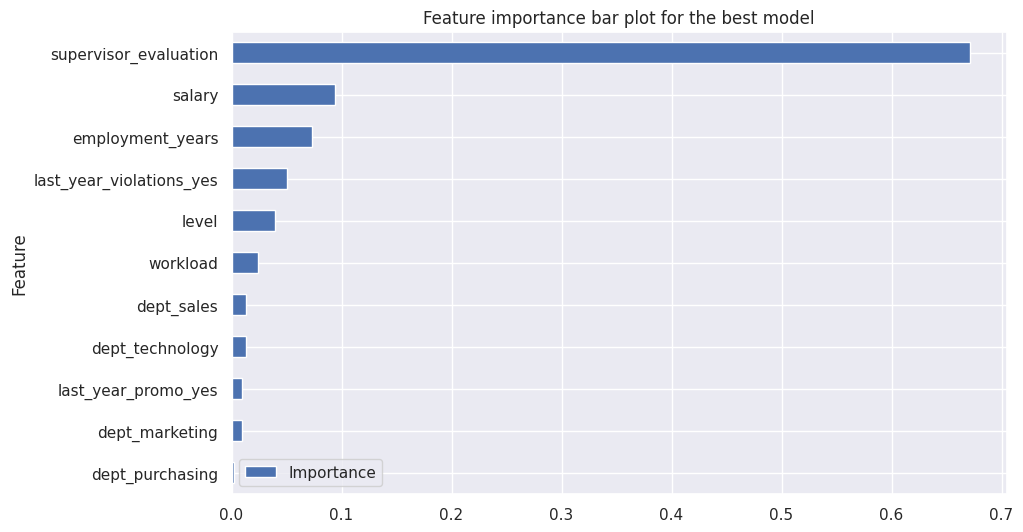

In [69]:
coeff_tree = rand_srch.best_estimator_[1].feature_importances_
train_features = rand_srch.best_estimator_[0]
features = train_features.get_feature_names_out()
feature_importance = pd.DataFrame(
    {
        'Feature': features,
        'Importance': coeff_tree
    }
)
feature_importance['Feature'] = feature_importance['Feature'].apply(feat_imp_rename)
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10, 6),
    title='Feature importance bar plot for the best model'
    );

<br> As expected according to data correlatin analysis the greatest impact belongs to 'supervisor_evaluation' feature. However 'last_year_violations' feature is forth. The second is 'salary' feature, the third feature is 'employment_years'

## 1.6 Conclusion for Decision Tree Regressor

A job satisfaction rate prediction model has been developed. Two types of models were investigated - Linear Regression and Decision Tree Regression. Analysis showed that the best model is DecisionTreeRegressor type which has the following hyperparameters: max_depth=46, min_samples_leaf=3, min_samples_split=3.
<br>Feature importance analysis showed the 'supervisor_evaluation' feature makes the major impact in model result. The second impacting feature is 'salary', the third impacting feature is 'employment_years'.

# 2. Employee quit predicting model

This section is devoted to model that predicts decision of employee to quit.
<br>Since target feature is binary and takes only two values (0, 1) the problem type is a binary classification.

## 2.1 Input data preparation

### 2.1.1 Data uploading

Data uploading set:

In [70]:
try:
	train_quit_df = pd.read_csv('/datasets/train_quit.csv', sep=',')
	test_target_quit_df = pd.read_csv('/datasets/test_target_quit.csv', sep=',')
except:
	train_quit_df = pd.read_csv('https://code.s3.yandex.net/datasets/train_quit.csv', sep=',')
	test_target_quit_df = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_quit.csv', sep=',')

Data reading check:

In [71]:
train_quit_df.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [72]:
test_target_quit_df.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


### 2.1.2 Data preparation

#### Dataframe train_quit_df

In [73]:
train_quit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [74]:
train_quit_df.isna().sum()

,0
id,0
dept,0
level,0
workload,0
employment_years,0
last_year_promo,0
last_year_violations,0
supervisor_evaluation,0
salary,0
quit,0


In [75]:
train_quit_df.duplicated().sum()

np.int64(0)

No duplicates or missing data found

#### Dataframe test_target_quit_df

In [76]:
test_target_quit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


Join dataframe of the test dataset with dataframe containing target feature:

In [77]:
test_full_quit = test_featrues_rev_df.merge(test_target_quit_df , on='id')
test_full_quit = test_full_quit.merge(test_target_df, on='id')
test_full_quit.head()

,dept,level,id,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,marketing,junior,485046,medium,2,no,no,5,28800,no,0.79
1,hr,junior,686555,medium,1,no,no,4,30000,no,0.72
2,sales,middle,467458,low,5,no,no,4,19200,no,0.64
3,sales,middle,418655,low,6,no,no,4,19200,no,0.60
4,hr,middle,789145,medium,5,no,no,5,40800,no,0.75


In [78]:
test_full_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   2000 non-null   object 
 1   level                  2000 non-null   object 
 2   id                     2000 non-null   int64  
 3   workload               2000 non-null   object 
 4   employment_years       2000 non-null   int64  
 5   last_year_promo        2000 non-null   object 
 6   last_year_violations   2000 non-null   object 
 7   supervisor_evaluation  2000 non-null   int64  
 8   salary                 2000 non-null   int64  
 9   quit                   2000 non-null   object 
 10  job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


The expected missing data will be filled using pipeline.

## 2.2 Data analysis

### 2.2.1 Training dataset analysis

Since dataset contains the same features as the dataset from previous analysis (section [1.2.1]) the same type of plots are output below:

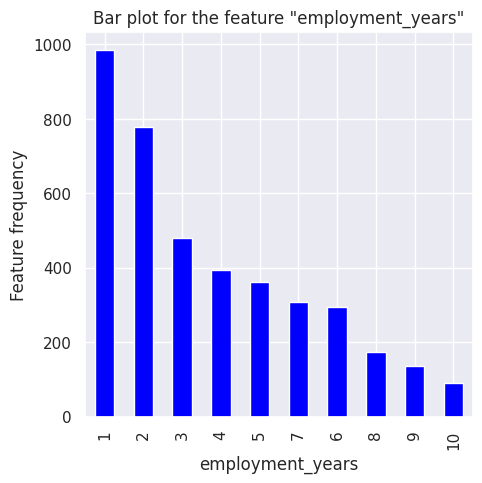

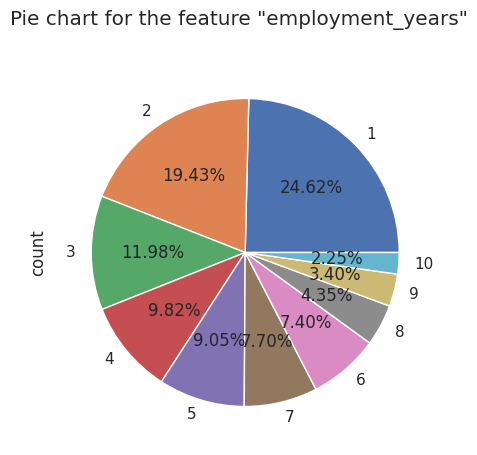

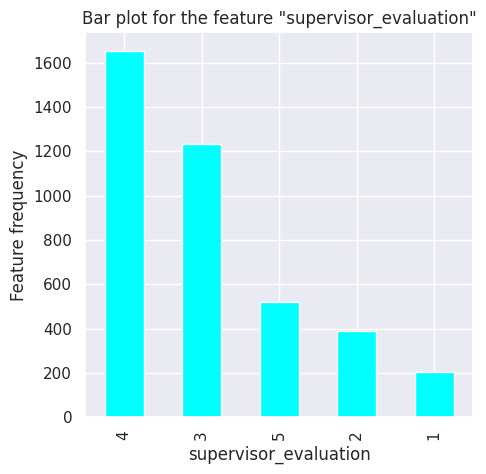

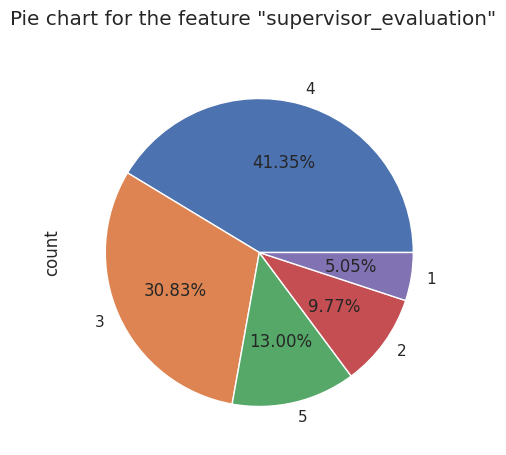

In [79]:
for i in range(len(descr_col)):
    plt.rcParams['figure.figsize'] = [5, 5]
    plt_name = 'Bar plot for the feature "' + descr_col[i] + '"'
    train_quit_df[descr_col[i]].value_counts().plot(
                kind='bar',
                xlabel = descr_col[i],
                ylabel = 'Feature frequency',
                title=plt_name,
                color = color[i]
              );
    plt.show()
    train_quit_df[descr_col[i]].value_counts().plot(
        kind='pie', autopct='%.2f%%');
    title = 'Pie chart for the feature "' + descr_col[i] + '"'
    plt.suptitle(title)
    plt.show()
    print()

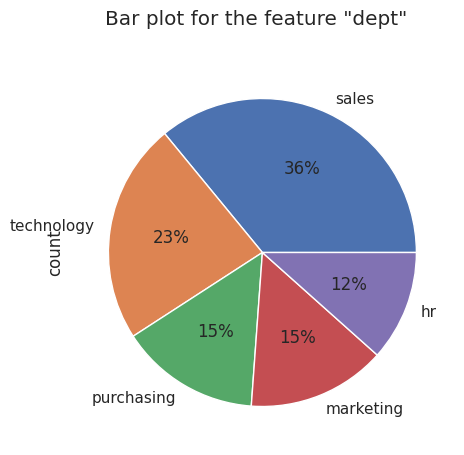

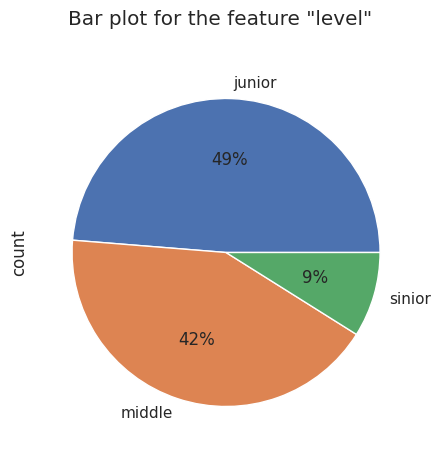

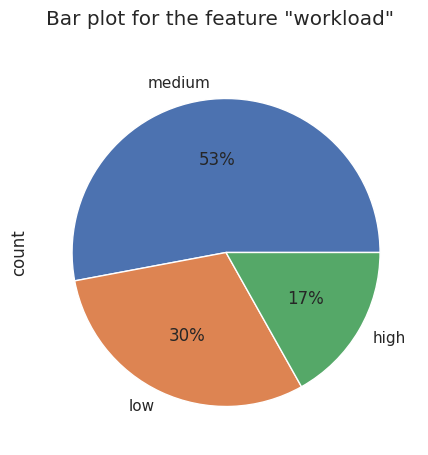

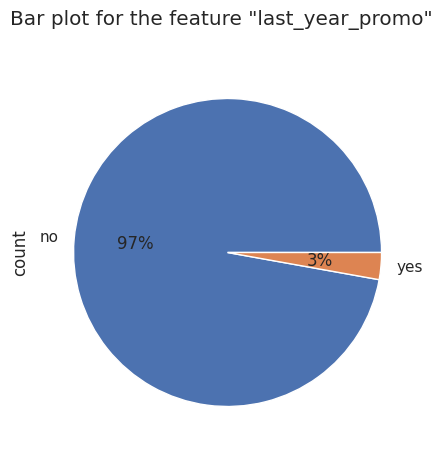

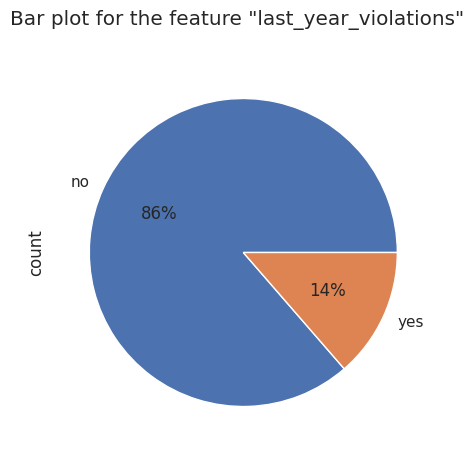

In [80]:
for i in range(len(cat_col)):
    plt.rcParams['figure.figsize'] = [5, 5]
    train_quit_df[cat_col[i]].value_counts().plot(kind='pie', autopct='%.0f%%');
    title = 'Bar plot for the feature "' + cat_col[i] + '"'
    plt.suptitle(title)
    plt.show()
    print() # для отделения графиков

Data values distribution is the same as shown in section 1. No anomalies were found.

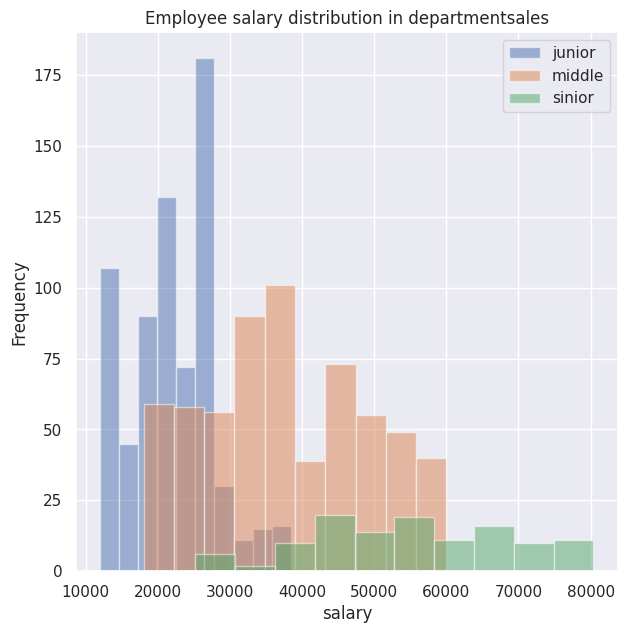

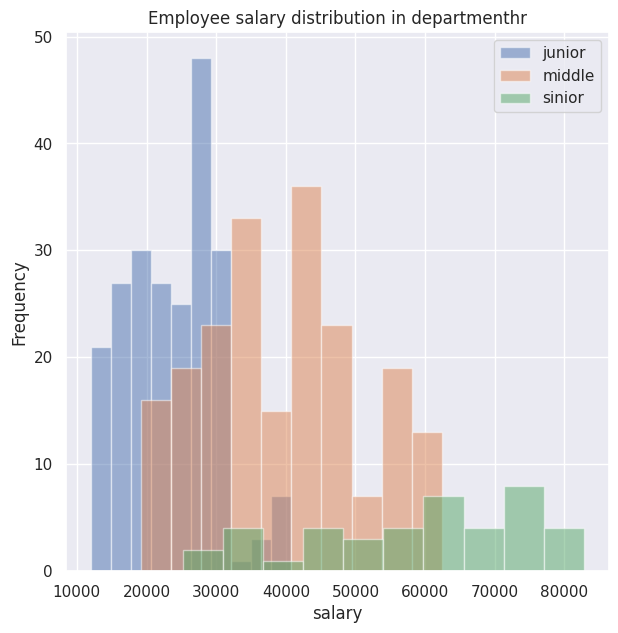

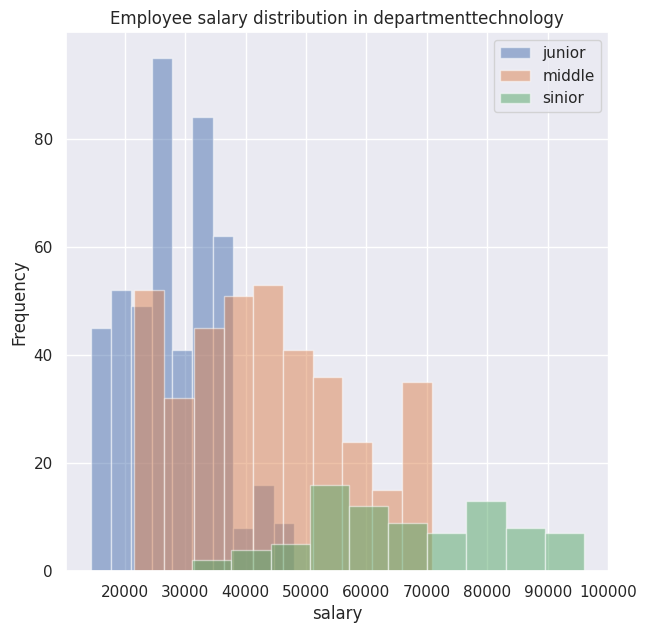

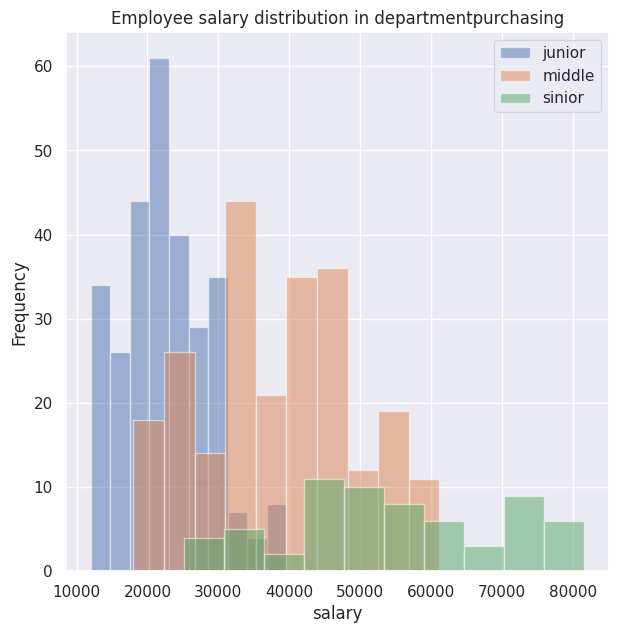

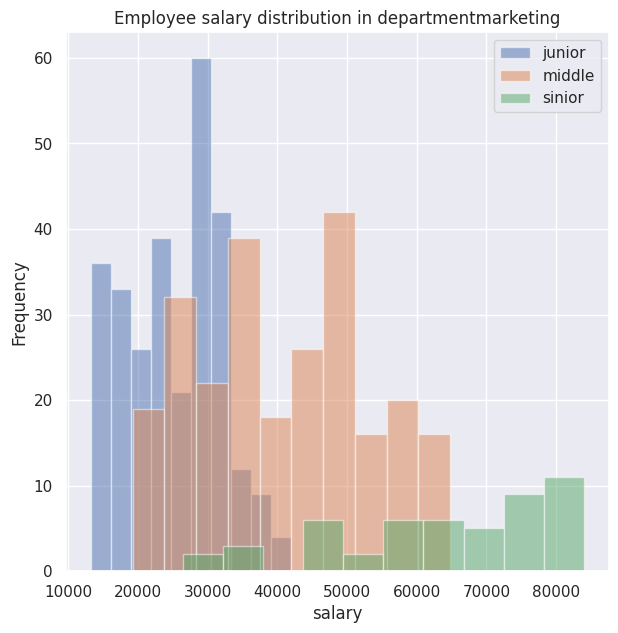

In [81]:
depts = train_js_rate_rev_df['dept'].unique()
for elm in depts:
    title_salary = 'Employee salary distribution in department' + elm
    train_quit_df[train_quit_df['dept'] == elm].groupby('level')['salary'].plot(
        kind='hist',
        bins=10,
        figsize=(7, 7),
        xlabel='salary',
        alpha = 0.5,
        title=title_salary,
        legend=True
    );
    plt.show();
    print()

Analysis of the target feature "quit".
<br> It would be helpful to describe features of the employee who is a candidate to quit, make a 'portrait' of him or her.
<br> To solve this problem data for each department and workload of employees will be analyzed.
<br> In addition a comparision of average salary of working and left employees will be done.  

A distribution of working and quit employees by department is shown below.

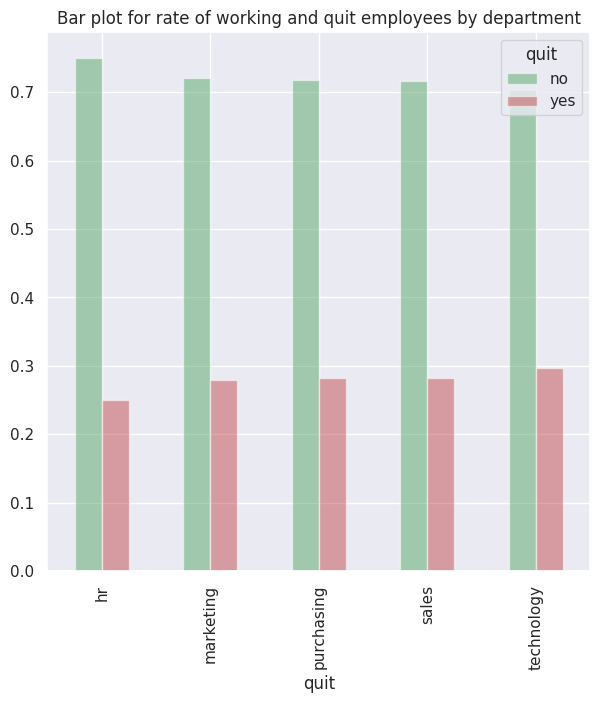

In [82]:
title_salary = 'Bar plot for rate of working and quit employees by department'
train_quit_df.groupby('dept')['quit'].value_counts(normalize=True).unstack().plot(
      kind='bar',
      figsize=(7, 7),
      xlabel='quit',
      alpha = 0.5,
      title=title_salary,
      color=['g', 'r']
    );

Plots show that the precentage of left employees is high in technology department.
<br>
<br> Plots below illustrate distribution of quit and working employees by department and level.

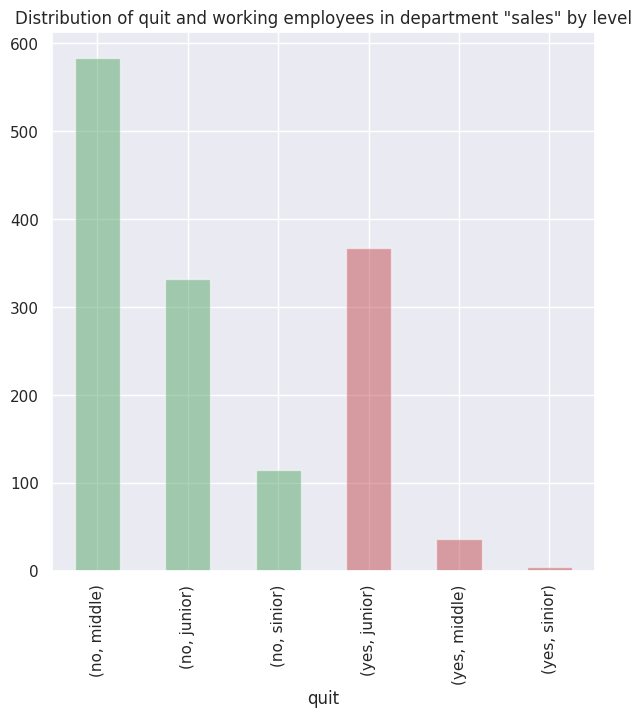

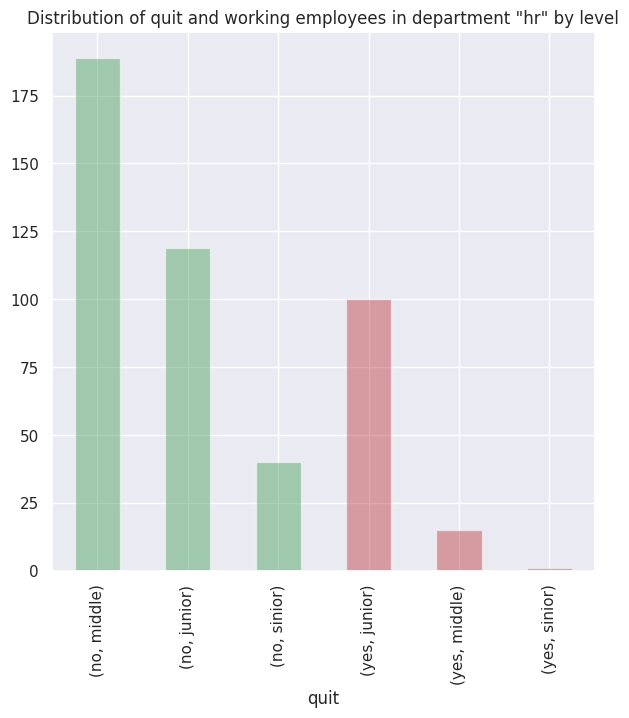

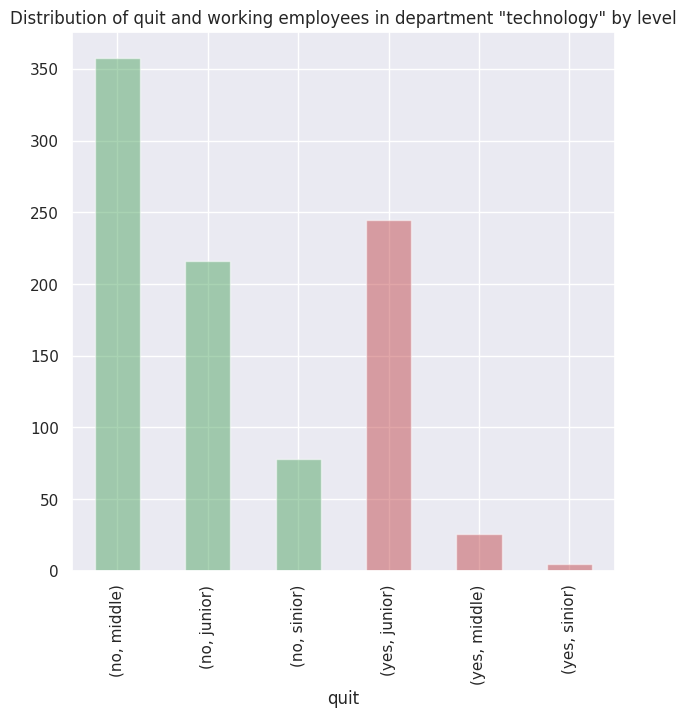

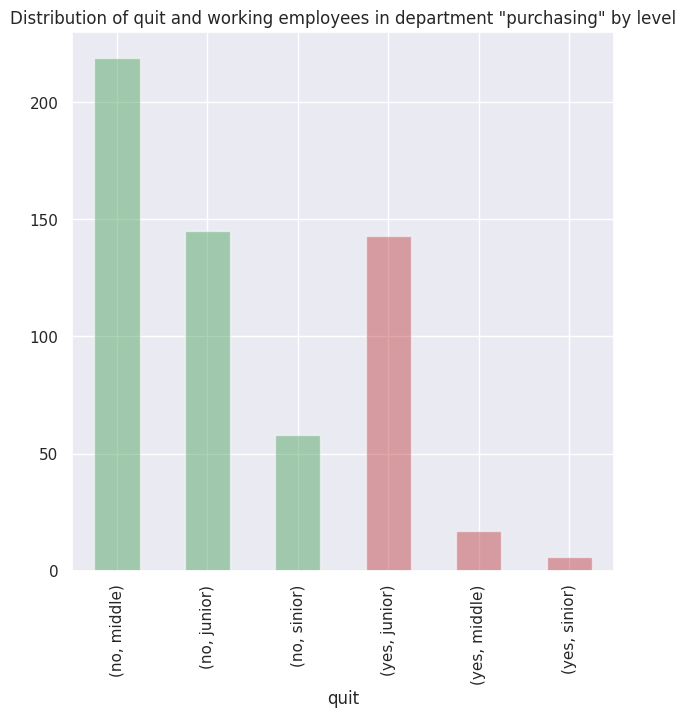

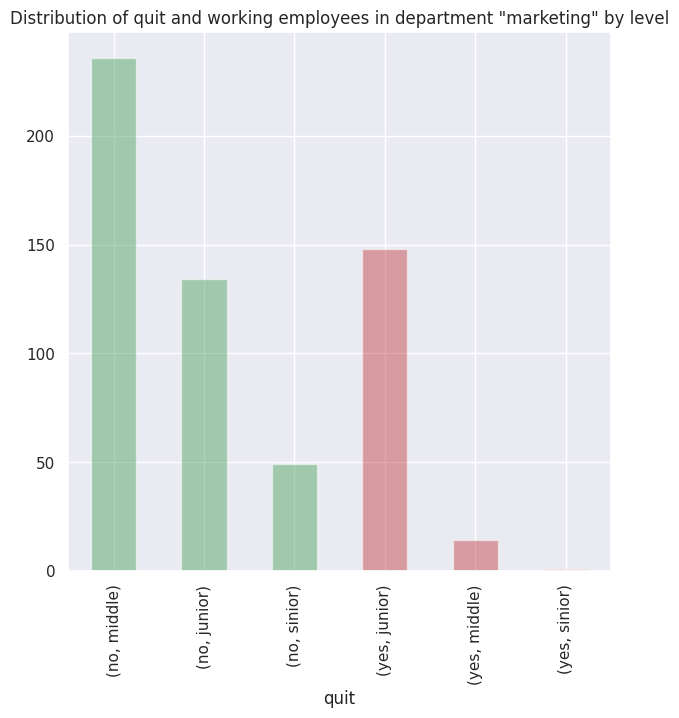

In [83]:
for elm in depts:
    title_salary = 'Distribution of quit and working employees in department "' + elm + '" by level'
    train_quit_df[train_quit_df['dept'] == elm].groupby('quit')['level'].value_counts().plot(
        kind='bar',
        figsize=(7, 7),
        xlabel='quit',
        alpha = 0.5,
        title=title_salary,
        color=['g', 'g', 'g', 'r', 'r', 'r']
    );
    plt.show();
    print()

Based on plots it may be concluded that there is a common trend. Junior employees are the leaders in quitting the job. Only in HR department the percentage of working employees is higher than the precentage of quit. Purchasing department shows almost 50% of quit junior employees. Other departments have more quit junior employees than currently working.
<br>Number of quit employees with middle level is less than working for all departments. The lowes percantege of quit is for senior specialists.

Plots below are based on employees workload groupping by department.

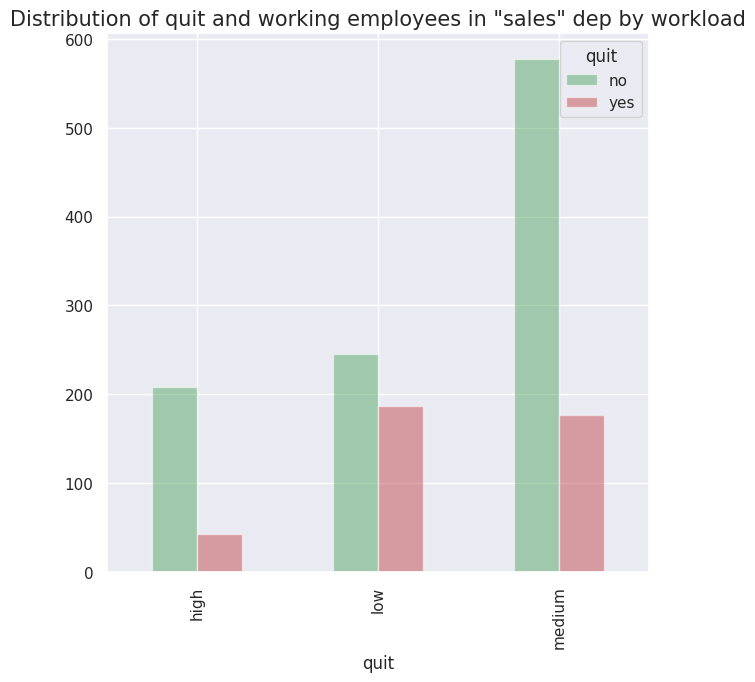

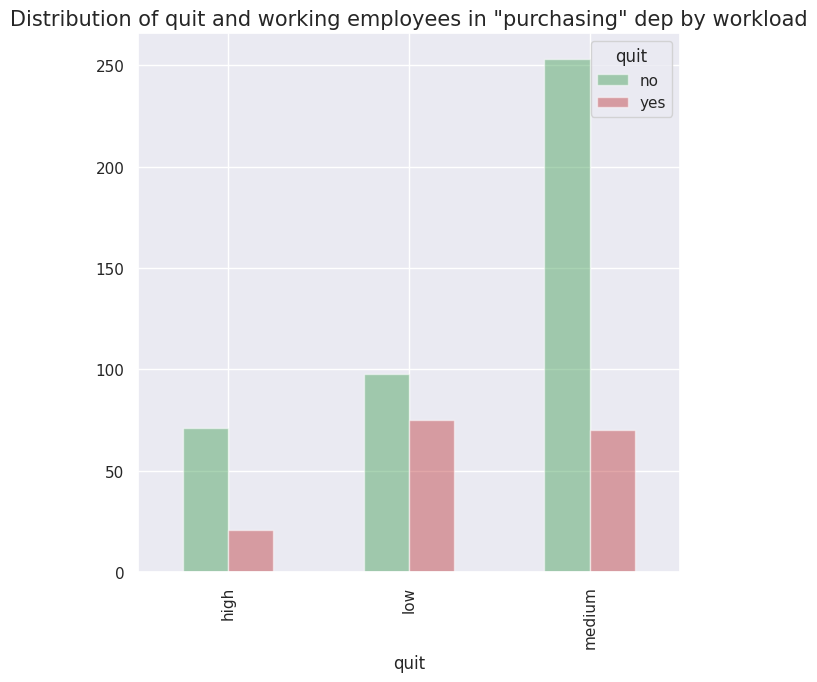

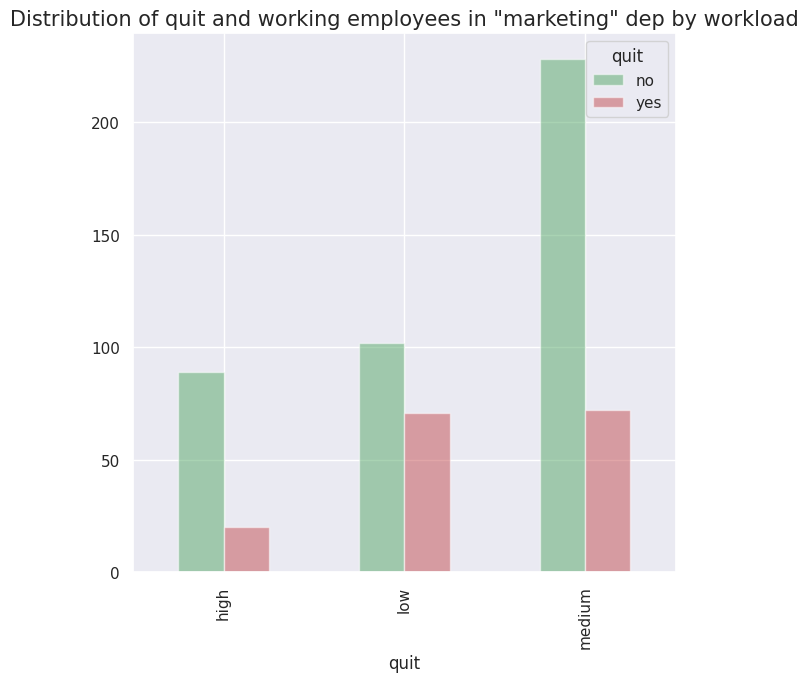

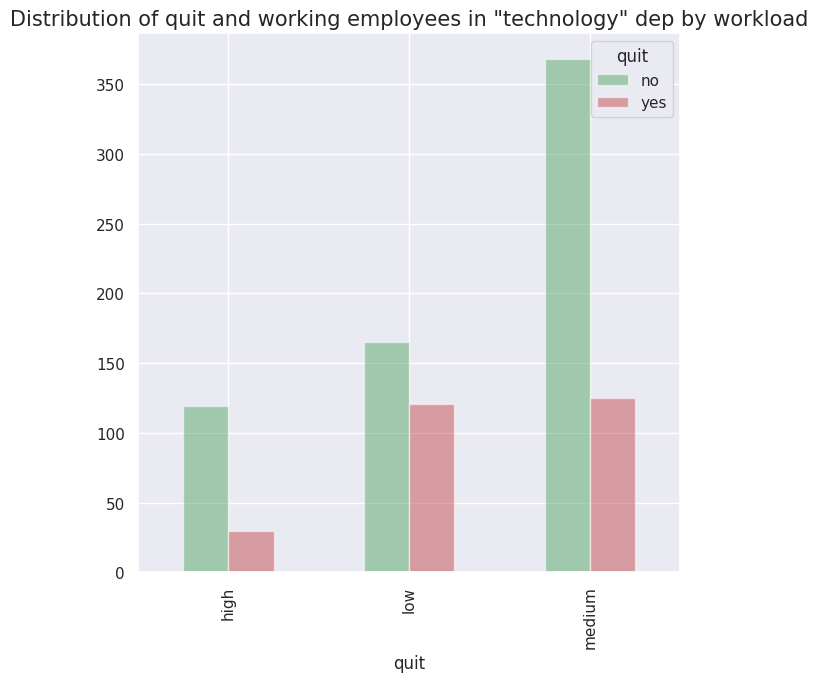

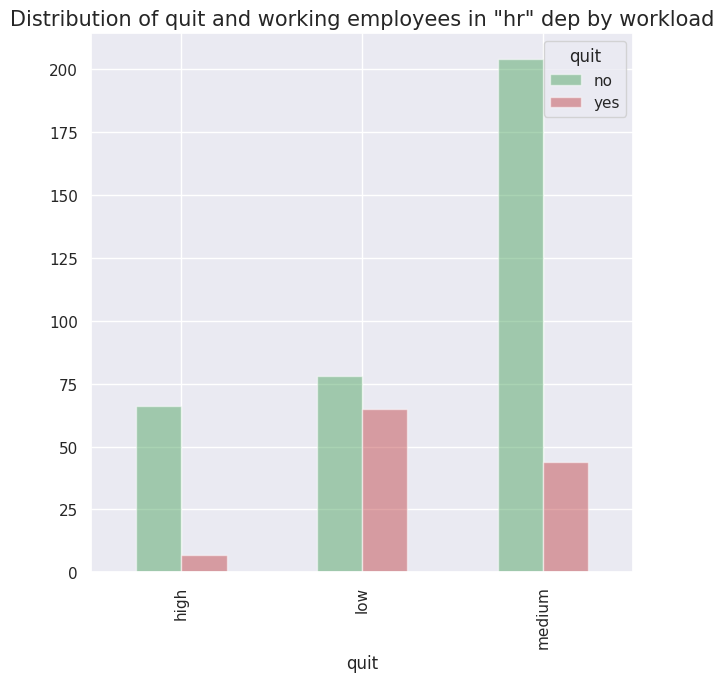

In [84]:
for elm in train_quit_df['dept'].unique():
    title_name = 'Distribution of quit and working employees in "'+ elm + '" dep by workload'
    train_quit_df[train_quit_df['dept'] == elm].groupby('workload')['quit'].value_counts().unstack().plot(
        kind='bar',
        figsize=(7, 7),
        xlabel='quit',
        alpha = 0.5,
        color=['g', 'r']
      );
    plt.title(title_name, fontsize = 15)
    plt.show()
    print()

Based on plots portion of quit employees with low workload is the biggest in each department.

Plot average salary of quit and working employees.
<br> As shown in previous analysis average salary differes for employee level. Hence data in plots should be grouped by 'level' feature.

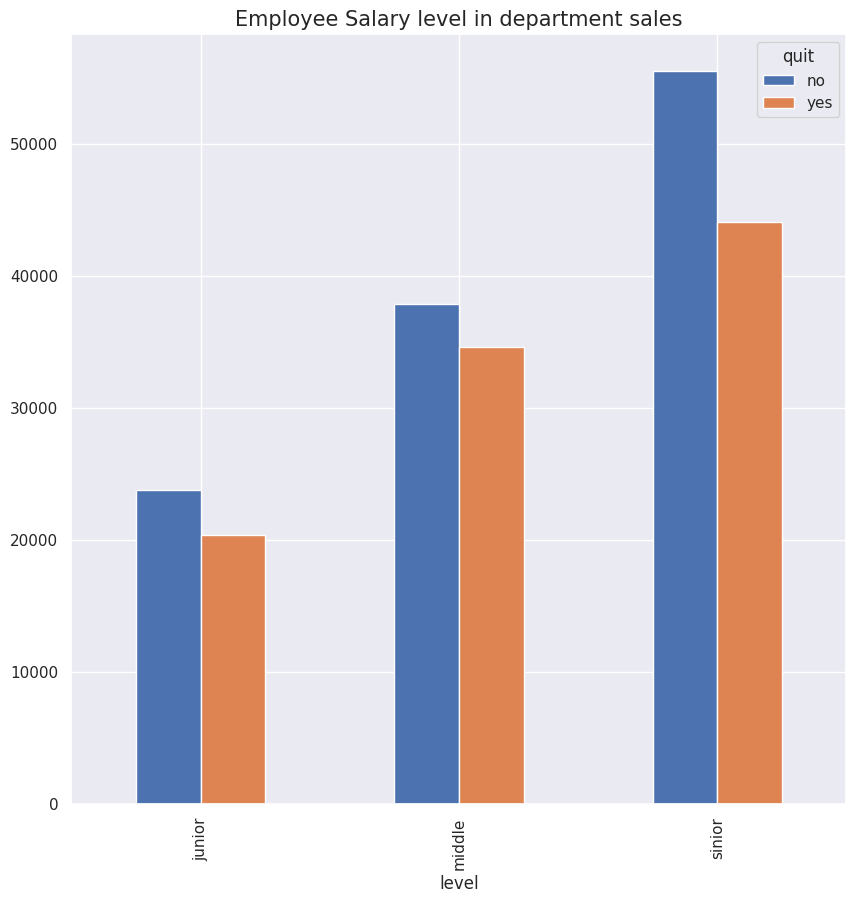

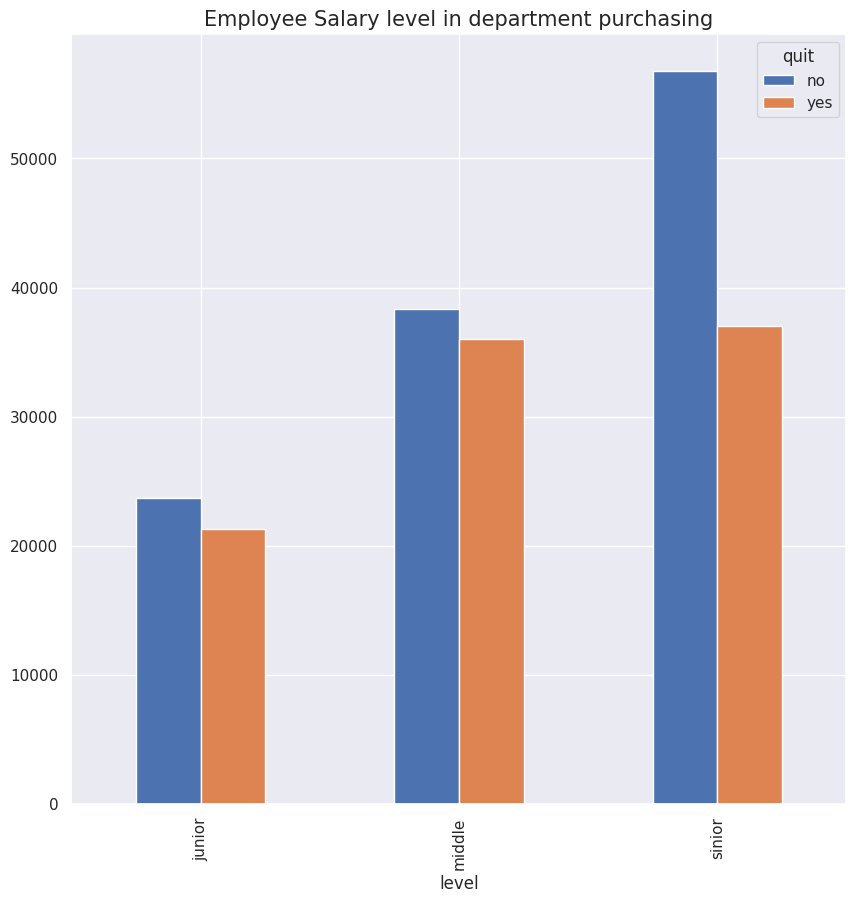

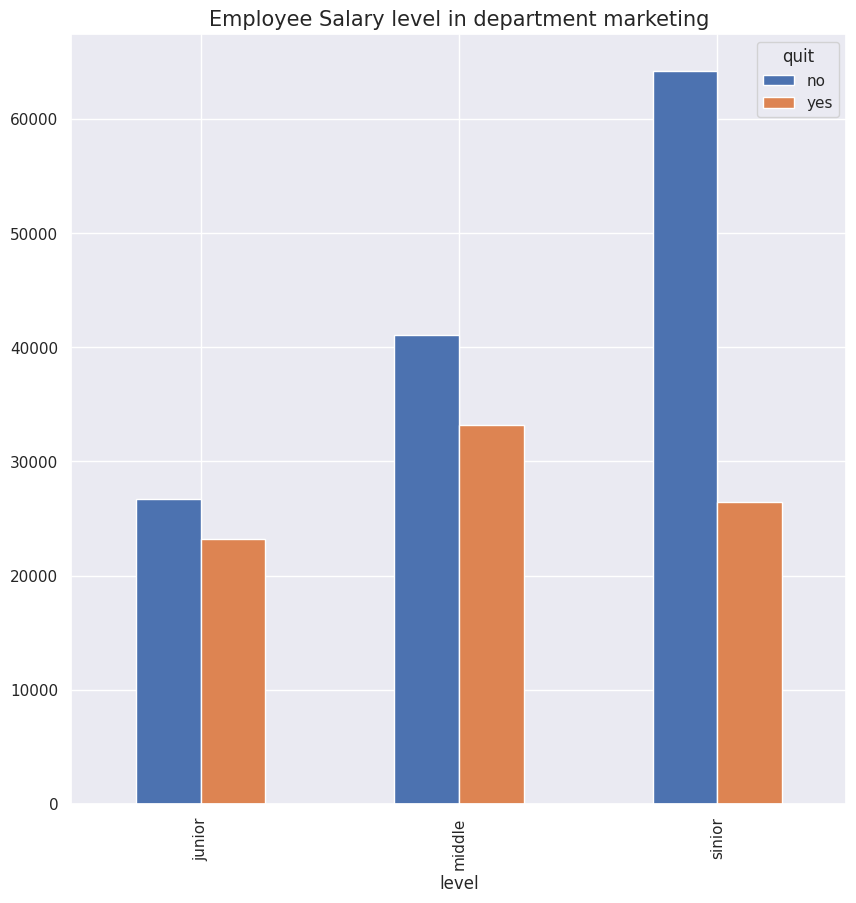

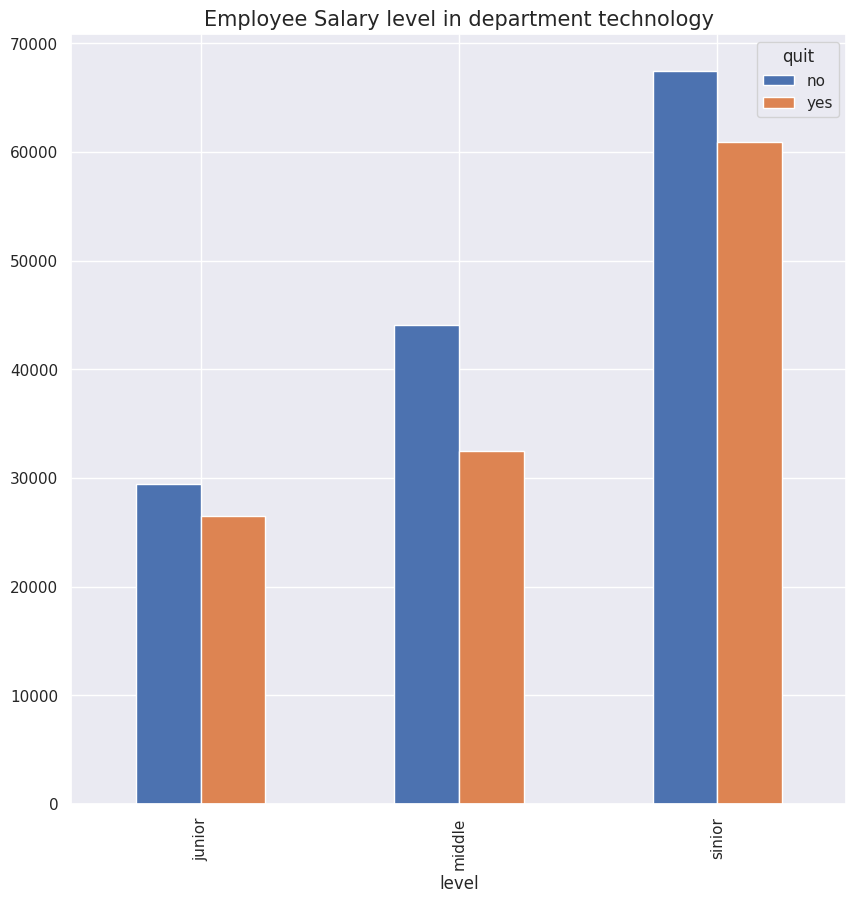

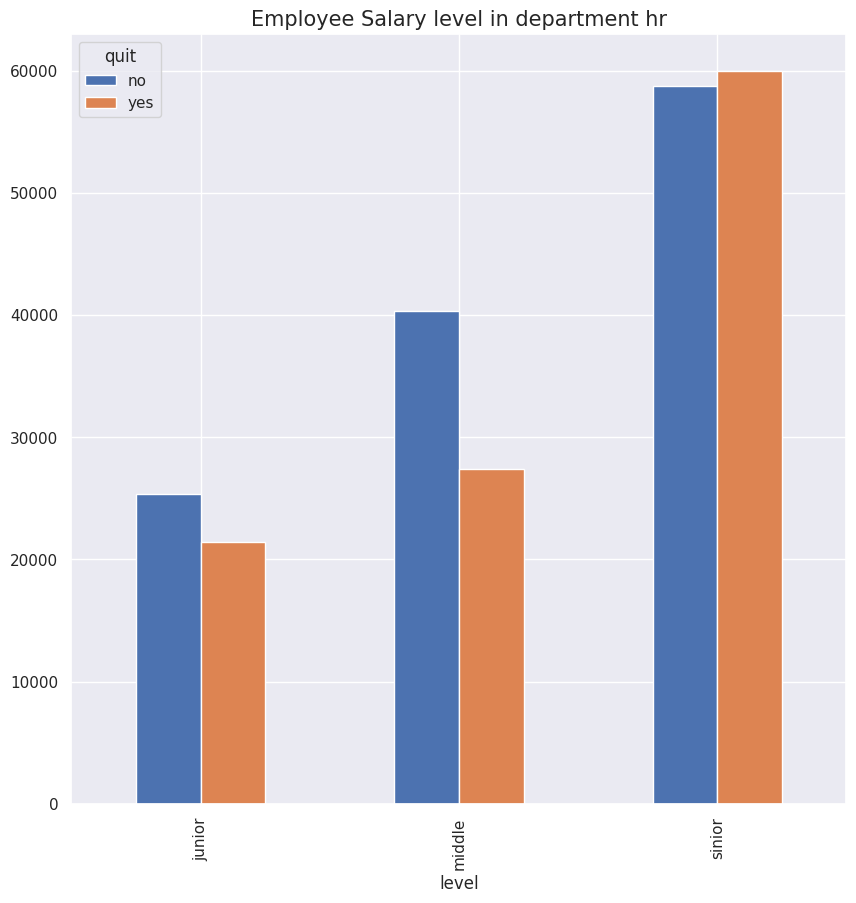

In [85]:
#elm = 'sales'
for elm in train_quit_df['dept'].unique():
    plt.rcParams['figure.figsize'] = [10, 10]
    title_name = 'Employee Salary level in department ' + elm
    train_quit_df[train_quit_df['dept'] == elm]\
              .groupby(['level', 'quit'])['salary']\
              .mean().unstack().plot(
                  kind='bar',
              );
    plt.title(title_name, fontsize = 15)
    plt.show()
    print()

Plots show that quit employees of junior level had almost the same salary level as those who continued to work. This trend is the same in every department.
<br> However quit middle level employees from HR, technology and marketing might left due to lower income as opposed to those who stayed.
<br> It is clearly shown that quit senior level employees from marketing and purchasing department earned much less (in average) than those who continued to work. However HR department shows the opposite trend probably due to some other issues.

Hence, a 'portrait' of quit employee in this company looks like this:
* this employee has a 'junior' level;
* his/her workload level is 'low';
* the average salary of this employee is less than for others;
* this employee probably works in 'sales' department.

### 2.2.2 Test dataset analysis

Some analysts state that job satisfaction rate impacts the decision of employee to stay or quit.
<br>Check this statementnfor test dataset, that contains both 'job_satisfaction_rate' and 'quit' features.
<br>Output a bar plot for this purpose.

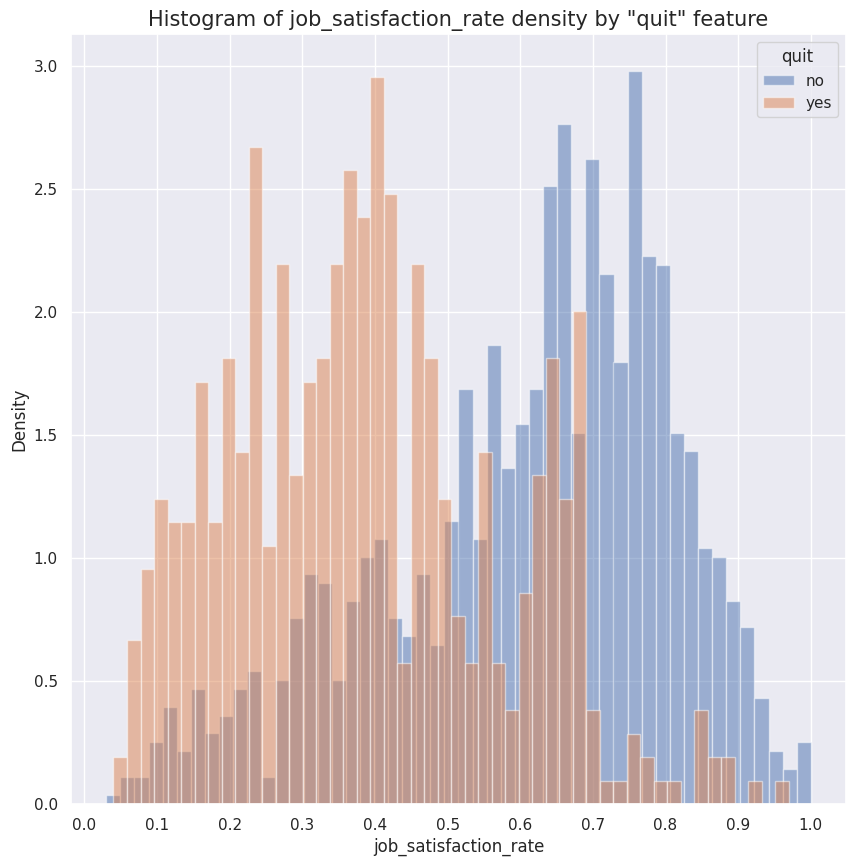

In [86]:
test_full_quit.groupby('quit')['job_satisfaction_rate'].plot(
      kind='hist',
      bins=50,
      figsize=(10, 10),
        alpha = 0.5,
      title=title_salary,
      legend=True,
      ec='black',
      xticks=np.linspace(0, 1, 11),
      density=True
    );
plt.title('Histogram of job_satisfaction_rate density by "quit" feature', fontsize = 15)
plt.legend(title='quit')
plt.ylabel('Density')
plt.xlabel('job_satisfaction_rate')
plt.show();

The histogram shows that job_satisfaction_rate density distribution for working employees is bimodal, meanwhile quit employees have multymodal distribution.
<br>Quit employees have high density at job_satisfaction_rate value below 0.25 and in range between 0.35 to 0.4. Then the density decreses and the next peak lies in range [0.6; 0.7].
<br>It can be concluded that:
* if job satisfaction rate is low (below 0.3) the probabiloty of employee to quit is high;
* for job satisfaction level above 0.7 probability of quitting is low;
* the range between 0.3 and 0.7 has several peaks and does not show clear trend which may result in other features impact.

### 2.2.3 Data analysis results

During the data analysis, no anomalies were detected. The distribution of features was consistent with the data from the first part of the project.

Based on the analysis, a profile of an employee prone to leaving the company was developed. This employee:

* holds a junior-level position;
* has a low workload;
* receives a lower-than-average salary compared to other employees at the same level;
* is most likely employed in the sales department.
<br>Additionally, the impact of job satisfaction on employee turnover was examined. A clear pattern was identified:
* employees with low satisfaction levels are highly likely to leave;
* those with high satisfaction levels are much less likely to resign.
<br>However, in the mid-range of job satisfaction (from moderately low to moderately high), the relationship is not linear. Local peaks in turnover were observed, and there is no consistent downward trend in resignations as satisfaction increases. This may indicate the influence of additional factors that were not accounted for.


## 2.3 Adding job_satisfaction_rate as input feature

Using the model from the first part of the project use it to predict job_satisfaction_rate:

In [87]:
y_pred = rand_srch.predict(train_quit_df.drop(['id', 'quit'], axis=1))

Add predicted values of job satisfaction rate to training dataset.

In [88]:
train_quit_df['job_satisfaction_rate'] = y_pred
train_quit_df.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.606667
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.821905
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.326667
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.337500
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.812500


Data successfully added and ready for analysis.

In [89]:
y_pred_2 = rand_srch.predict(X_test)
test_full_quit['job_satisfaction_rate'] = y_pred_2
test_full_quit.head()

,dept,level,id,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,marketing,junior,485046,medium,2,no,no,5,28800,no,0.883333
1,hr,junior,686555,medium,1,no,no,4,30000,no,0.682222
2,sales,middle,467458,low,5,no,no,4,19200,no,0.683750
3,sales,middle,418655,low,6,no,no,4,19200,no,0.713333
4,hr,middle,789145,medium,5,no,no,5,40800,no,0.812500


## 2.4 Data check for correlation

Create phik correlation matrix for the training dataset.

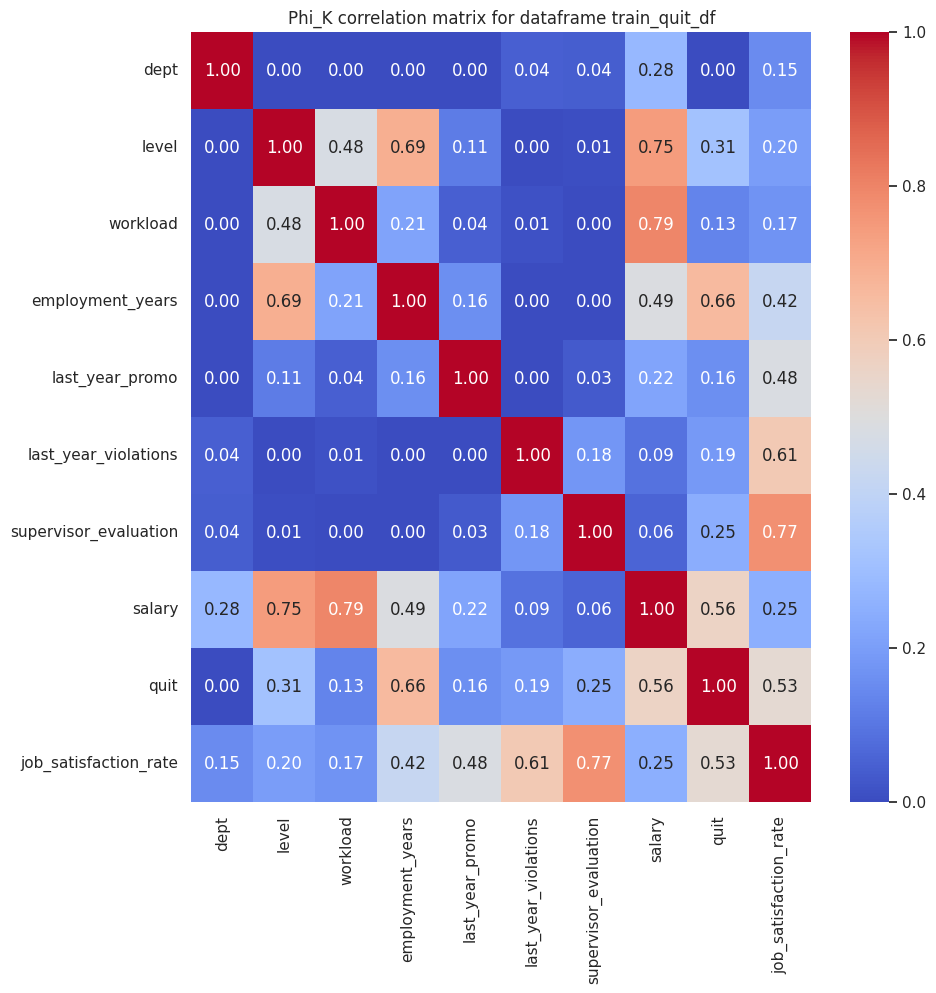

In [90]:
sns.set (rc = {'figure.figsize':(10, 10)})
plt.title('Phi_K correlation matrix for dataframe train_quit_df')
sns.heatmap(
    train_quit_df.drop('id', axis=1)\
    .phik_matrix(
      interval_cols=['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']
    ), annot=True, fmt='.2f', cmap='coolwarm'
);
plt.show();

Plot shows that target feature 'quit' correlates with the following:
* employment_years - value 0.66;
* salary - value 0.56;
* job_satisfaction_rate - value 0.51.

## 2.5 Dataset preparation for the model training

Since data already consists of separate training and test datasets train_test_split procedure is ommited. Remove 'id' feature from the sets.
<br>Target feature will be coded using LabelEncoder.

In [91]:
X_train = train_quit_df.drop(['id', 'quit'], axis=1)
X_test = test_full_quit.drop(['id', 'quit'], axis=1)
#coding of target
label = LabelEncoder()
y_train = label.fit_transform(train_quit_df['quit'])
y_test = label.transform(test_full_quit['quit'])

## 2.6 Model training

The problem of employee quit prediction is a binary classification type of problem. Three models - kNN, DecisionTreeClassifier and SVC are used for solution.
<br>RandomizedSearchCV is used to obtain the best model using ROC AUC as scoring parameter value.

In [92]:
param_distr = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preproc__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [DecisionTreeClassifier(random_state = RANDOM_STATE)],
        'models__max_depth': range(2, 50),
        'models__min_samples_leaf': range(1, 10),
        'models__min_samples_split': range(2, 10),
        'preproc__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [SVC(
            random_state = RANDOM_STATE,
            kernel='rbf',
            probability=True
            )],
        'models__gamma': [0.01, 0.1, 1, 5, 10],
        'preproc__num': [StandardScaler(), MinMaxScaler()]
    }
]

In [93]:
rand_srch = RandomizedSearchCV(
    pipe_final,
    param_distr,
    cv = 5,
    scoring='roc_auc',
    random_state = RANDOM_STATE,
    n_jobs=-1,
)

Add job_satisfaction_rate feature in the list of numerical features for scaling:

In [94]:
num_columns.append('job_satisfaction_rate')
num_columns

['employment_years', 'salary', 'job_satisfaction_rate']

In [95]:
rand_srch.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preproc',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('imp',
                                                                                                Pipeline(steps=[('sim_imp',
                                                                                                                 SimpleImputer(strategy='most_frequent'))])),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['dept',
                                                                                'last_year_promo',
                                                                                'last_year_violations'])...
                                        {'models': [DecisionTreeClassifier(random_state=50)],
                                         'models__max_depth': range(2, 50),
                                         'models__min_samples_leaf': range(1, 10),
                                         'models__min_samples_split': range(2, 10),
                                         'preproc__num': [StandardScaler(),
                                                          MinMaxScaler()]},
                                        {'models': [SVC(probability=True,
                                                        random_state=50)],
                                         'models__gamma': [0.01, 0.1, 1, 5, 10],
                                         'preproc__num': [StandardScaler(),
                                                          MinMaxScaler()]}],
                   random_state=50, scoring='roc_auc')

Output the top 10 best models:



In [96]:
result = pd.DataFrame(rand_srch.cv_results_)
result[['rank_test_score', 'param_models', 'mean_test_score','params']].sort_values('rank_test_score')

,rank_test_score,param_models,mean_test_score,params
1,1,DecisionTreeClassifier(random_state=50),0.923403,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 2, 'models__min_samples_leaf': 8, 'models__max_depth': 40, 'models': DecisionTreeClassifier(random_state=50)}"
4,1,DecisionTreeClassifier(random_state=50),0.923403,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 9, 'models__min_samples_leaf': 8, 'models__max_depth': 15, 'models': DecisionTreeClassifier(random_state=50)}"
3,3,DecisionTreeClassifier(random_state=50),0.913798,"{'preproc__num': MinMaxScaler(), 'models__min_samples_split': 8, 'models__min_samples_leaf': 3, 'models__max_depth': 45, 'models': DecisionTreeClassifier(random_state=50)}"
2,4,DecisionTreeClassifier(random_state=50),0.913784,"{'preproc__num': MinMaxScaler(), 'models__min_samples_split': 7, 'models__min_samples_leaf': 3, 'models__max_depth': 15, 'models': DecisionTreeClassifier(random_state=50)}"
0,5,DecisionTreeClassifier(random_state=50),0.910214,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 2, 'models__min_samples_leaf': 3, 'models__max_depth': 42, 'models': DecisionTreeClassifier(random_state=50)}"
7,6,DecisionTreeClassifier(random_state=50),0.902538,"{'preproc__num': MinMaxScaler(), 'models__min_samples_split': 4, 'models__min_samples_leaf': 2, 'models__max_depth': 46, 'models': DecisionTreeClassifier(random_state=50)}"
6,7,DecisionTreeClassifier(random_state=50),0.894445,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 5, 'models__min_samples_leaf': 1, 'models__max_depth': 45, 'models': DecisionTreeClassifier(random_state=50)}"
9,8,DecisionTreeClassifier(random_state=50),0.887291,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 3, 'models__min_samples_leaf': 1, 'models__max_depth': 25, 'models': DecisionTreeClassifier(random_state=50)}"
5,9,DecisionTreeClassifier(random_state=50),0.880453,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 4, 'models__min_samples_leaf': 8, 'models__max_depth': 2, 'models': DecisionTreeClassifier(random_state=50)}"
8,9,DecisionTreeClassifier(random_state=50),0.880453,"{'preproc__num': StandardScaler(), 'models__min_samples_split': 5, 'models__min_samples_leaf': 4, 'models__max_depth': 2, 'models': DecisionTreeClassifier(random_state=50)}"


The best model shows ROC AUC equal to 0.92 for validation dataset.

Calculation of scoring using for test dataset:

In [97]:
y_pred = rand_srch.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_pred[:, 1])
print(f'Metric value for the test dataset is: {roc_auc:0.3f}')

Metric value for the test dataset is: 0.909


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best model is:

In [98]:
best_model = rand_srch.best_estimator_[1]
best_model

DecisionTreeClassifier(max_depth=40, min_samples_leaf=8, random_state=50)

Make a plot for feature importance of the created model:

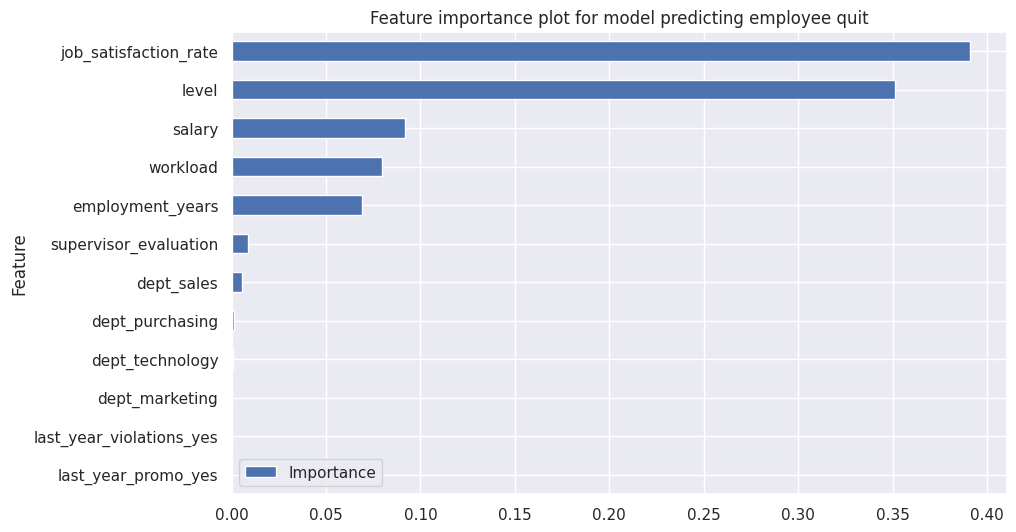

In [99]:
coeff_tree = rand_srch.best_estimator_[1].feature_importances_
train_features = rand_srch.best_estimator_[0]
features = train_features.get_feature_names_out()
feature_importance = pd.DataFrame(
    {
        'Feature': features,
        'Importance': coeff_tree
    }
)
feature_importance['Feature'] = feature_importance['Feature'].apply(feat_imp_rename)
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    title='Feature importance plot for model predicting employee quit',
    figsize=(10, 6)
    );

Plot shows that job satisfaction makes the major impact. The second important feature is level, then salary and workload.


## 2.7 Model conclusions


To solve the problem of employee quit prediction three classification  models were used with different hyperparameters. The best model is a DecisionTreeClassifier with max_depth=40, min_samples_leaf=8 and it showed ROC AUC value of 0.91 for the test data set.
<br>Feature importance output for the best model showes that 'job_satisfaction_rate' impacts most on the 'quit' value. The next feature is 'level' of employee. The following features are 'salary' and 'workload', but generally their impact is much lower.

# 3 Conclusions

During work on the project two Machine Learning models were created.
<br> The first model predicts employee job satisfaction rate using the following features:
* dept — the department where the employee works;
* level — level of the position held;
* workload — employee's workload level;
* employment_years — length of time worked for the company (in years);
* last_year_promo — shows whether there has been an increase in the last year;
* last_year_violations — shows whether an employee has violated an employment contract in the last year;
* supervisor_evaluation — the employee's supervisor's assessment of the employee's performance;
* salary — monthly salary of the employee;
<br> The second model predicts employee decision to resign from the company using the features above and job satisfaction rate values.
<br> Before model creation and training input data are analysed for missing values and anomalities. Plots were created to illustrate data and make conclusions. Data correlation analysis was conducted.
<br> Pipelines were used for data coding and model preparations. RandomizedSearchCV was used to obtain the best model and corresponding parameters.
<br> Feature importance plots show that for job satisfaction rate predicting model a feature 'suprevisor_evaluation' impacts most. The second impacting factor is 'salary', and the third one is 'employment_years'.
<br> Model that predicts employee quit is impacted by 'job_satisfaction_rate' feature, 'level', 'salary' and 'workload'. The last two are at lower extent.
<br> Hence, in providing recommendations to an HR department looking at models, one can suggest defining key employees in each level and paying attention to the job satisfaction rate, which is generally dictated by supervisor evaluation, while also keeping in mind salary and workload. Finally, one shouldn’t forget that models give general outcomes; all in all an individual approach matters when one works with people who are needed.

